In [22]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# --- Step 1: 定义FITS文件路径 ---
# 将这里的路径替换为你自己电脑上的真实路径
fits_file_path = 'bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits'

# --- Step 2: 使用Astropy打开FITS文件 ---
hdul = fits.open(fits_file_path)
print("FITS文件成功打开！")

# --- Step 3: 查看文件结构 (可选，但非常推荐) ---
# .info()方法会打印出所有扩展的名称和基本信息，帮助你了解文件内容
print("\n文件结构信息:")
hdul.info()

FITS文件成功打开！

文件结构信息:
Filename: bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        13   (200, 200)   float64   
  2  PneE          1 BinTableHDU     29   80R x 5C   [K, K, K, D, D]   
  3  PeeE          1 BinTableHDU     29   120R x 5C   [K, K, K, D, D]   
  4  NZ_LENS       1 BinTableHDU     22   79R x 5C   [D, D, D, D, D]   
  5  NZ_SOURCE     1 BinTableHDU     36   119R x 8C   [D, D, D, D, D, D, D, D]   


In [12]:
hdul[3].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   40 / length of dimension 1                          
NAXIS2  =                  120 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    5 / number of table fields                         
2PTDATA =                    T                                                  
EXTNAME = 'PeeE    '                                                            
QUANT1  = 'GEF     '                                                            
QUANT2  = 'GEF     '                                                            
KERNEL_1= 'NZ_SOURCE'       

In [13]:
# 'covmat'扩展的数据存储在.data属性中
covmat = hdul['covmat'].data
print(f"\n协方差矩阵的形状: {covmat.shape}")


协方差矩阵的形状: (200, 200)


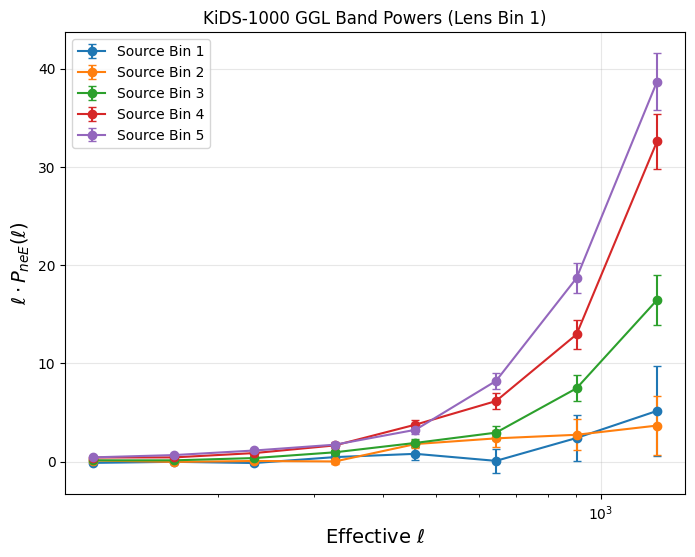

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# 1. 设定文件路径
fits_file = "bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits"

with fits.open(fits_file) as hdul:
    # 1. 读取 GGL 带通功率谱 (PneE)
    pnee_data = hdul['PneE'].data
    # 2. 读取协方差矩阵 (200x200)
    full_cov = hdul['COVMAT'].data
    
    # 在 KiDS 结构中，PneE 通常排在协方差矩阵的前部或后部
    # 根据此文件结构 (PneE 80个点, PeeE 120个点)
    # 假设 PneE 是前 80 个点
    err_all = np.sqrt(np.diag(full_cov))[:80]

    bin1 = pnee_data['BIN1']  # Lens bin (BOSS)
    bin2 = pnee_data['BIN2']  # Source bin (KiDS)
    # Band Powers 的 X 轴通常存放在 'ANG' 列，代表该带通的有效 ell
    ell_eff = pnee_data['ANG'] 
    value = pnee_data['VALUE']

    # 3. 绘图：选择一个 Lens Bin (比如 BOSS 的第一个 bin)
    # 对每一个 Source Bin (1-5) 画一条线
    lens_bin = 1
    plt.figure(figsize=(8, 6))

    for s_bin in range(1, 6):
        mask = (bin1 == lens_bin) & (bin2 == s_bin)
        
        if np.any(mask):
            # 提取该组合的 8 个带通数据点
            # KiDS 的带通通常每个 bin 组合有 8 个点
            current_ell = ell_eff[mask]
            current_val = value[mask]
            # 找到这些点在总 80 个点中的索引以提取误差
            idx = np.where(mask)[0]
            current_err = err_all[idx]

            plt.errorbar(current_ell, current_ell * current_val, yerr=current_ell * current_err,
                         fmt='-o', label=f'Source Bin {s_bin}', capsize=3)

    plt.xscale('log')
    # 物理习惯：通常画 ell * P(ell) 以突出信号
    plt.ylabel(r'$\ell \cdot P_{neE}(\ell)$', fontsize=14)
    plt.xlabel(r'Effective $\ell$', fontsize=14)
    plt.title(f"KiDS-1000 GGL Band Powers (Lens Bin {lens_bin})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

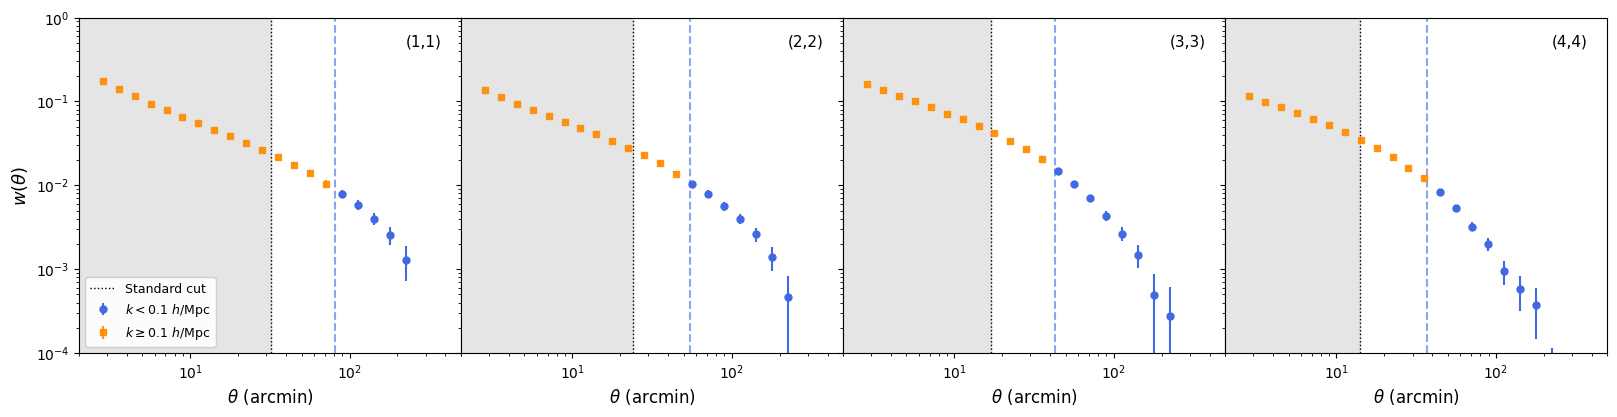

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 数据准备 ---
wtheta = hdul['wtheta'].data
cov = hdul['COVMAT'].data

start, end = 880, 1000
cov_w = cov[start:end, start:end]
err = np.sqrt(np.diag(cov_w))

bin1 = wtheta['BIN1']
bin2 = wtheta['BIN2']
theta = wtheta['ANG']
value = wtheta['VALUE']

bins_to_plot = [1, 2, 3, 4]
cut = [32, 24, 17, 14] # 原本的 Standard cut

# --- 2. 定义 k=0.1 的物理切分 ---
k_split = 0.05
# 填入你四个 bin 的平均共动距离 chi (单位: Mpc/h)。这里使用典型近似值：
lens_chis = [850.0, 1250.0, 1600.0, 1850.0] 

# --- 3. 开始画图 ---
fig, axes = plt.subplots(
    1, 4, figsize=(16, 4), sharex=False, sharey=False, gridspec_kw={'wspace': 0}
)

for i, b in enumerate(bins_to_plot):
    ax = axes[i]
    mask = (bin1 == b) & (bin2 == b)
    idx = np.where(mask)[0]
    
    th = theta[mask]
    val = value[mask]
    sigma = err[idx]

    # 计算该 bin 下 k=0.1 对应的角度 theta_split
    theta_split = (180.0 * 60.0 / np.pi) / (k_split * lens_chis[i])
    
    # 根据角度大小切分数据 (大角度 = 低 k，小角度 = 高 k)
    mask_low_k = th > theta_split
    mask_high_k = th <= theta_split

    # 绘制 k < 0.1 的数据点 (大尺度)
    ax.errorbar(
        th[mask_low_k], val[mask_low_k], yerr=sigma[mask_low_k],
        fmt='o', color='royalblue', ms=5, 
        label=r'$k < 0.1\ h/{\rm Mpc}$' if i == 0 else ""
    )
    
    # 绘制 k >= 0.1 的数据点 (小尺度)
    ax.errorbar(
        th[mask_high_k], val[mask_high_k], yerr=sigma[mask_high_k],
        fmt='s', color='darkorange', ms=5, alpha=0.9,
        label=r'$k \geq 0.1\ h/{\rm Mpc}$' if i == 0 else ""
    )

    # 绘制原本的 standard cut 背景
    ax.axvspan(0, cut[i], color='gray', alpha=0.2)
    ax.axvline(cut[i], color='black', ls=':', lw=1, label='Standard cut' if i==0 else "")
    
    # 可选：画一条辅助线指示 k=0.1 的位置
    ax.axvline(theta_split, color='royalblue', ls='--', lw=1.5, alpha=0.6)

    # 图表设置
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(2, 500)
    ax.set_ylim(1e-4, 1)

    ax.text(0.95, 0.95, f"({b},{b})", transform=ax.transAxes, ha='right', va='top', fontsize=11)

    if i == 0:
        ax.set_ylabel(r'$w(\theta)$', fontsize=13)
        ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
    else:
        ax.set_yticklabels([])

    ax.set_xlabel(r'$\theta\ (\mathrm{arcmin})$', fontsize=12)

plt.tight_layout(pad=0.1) 
plt.show()

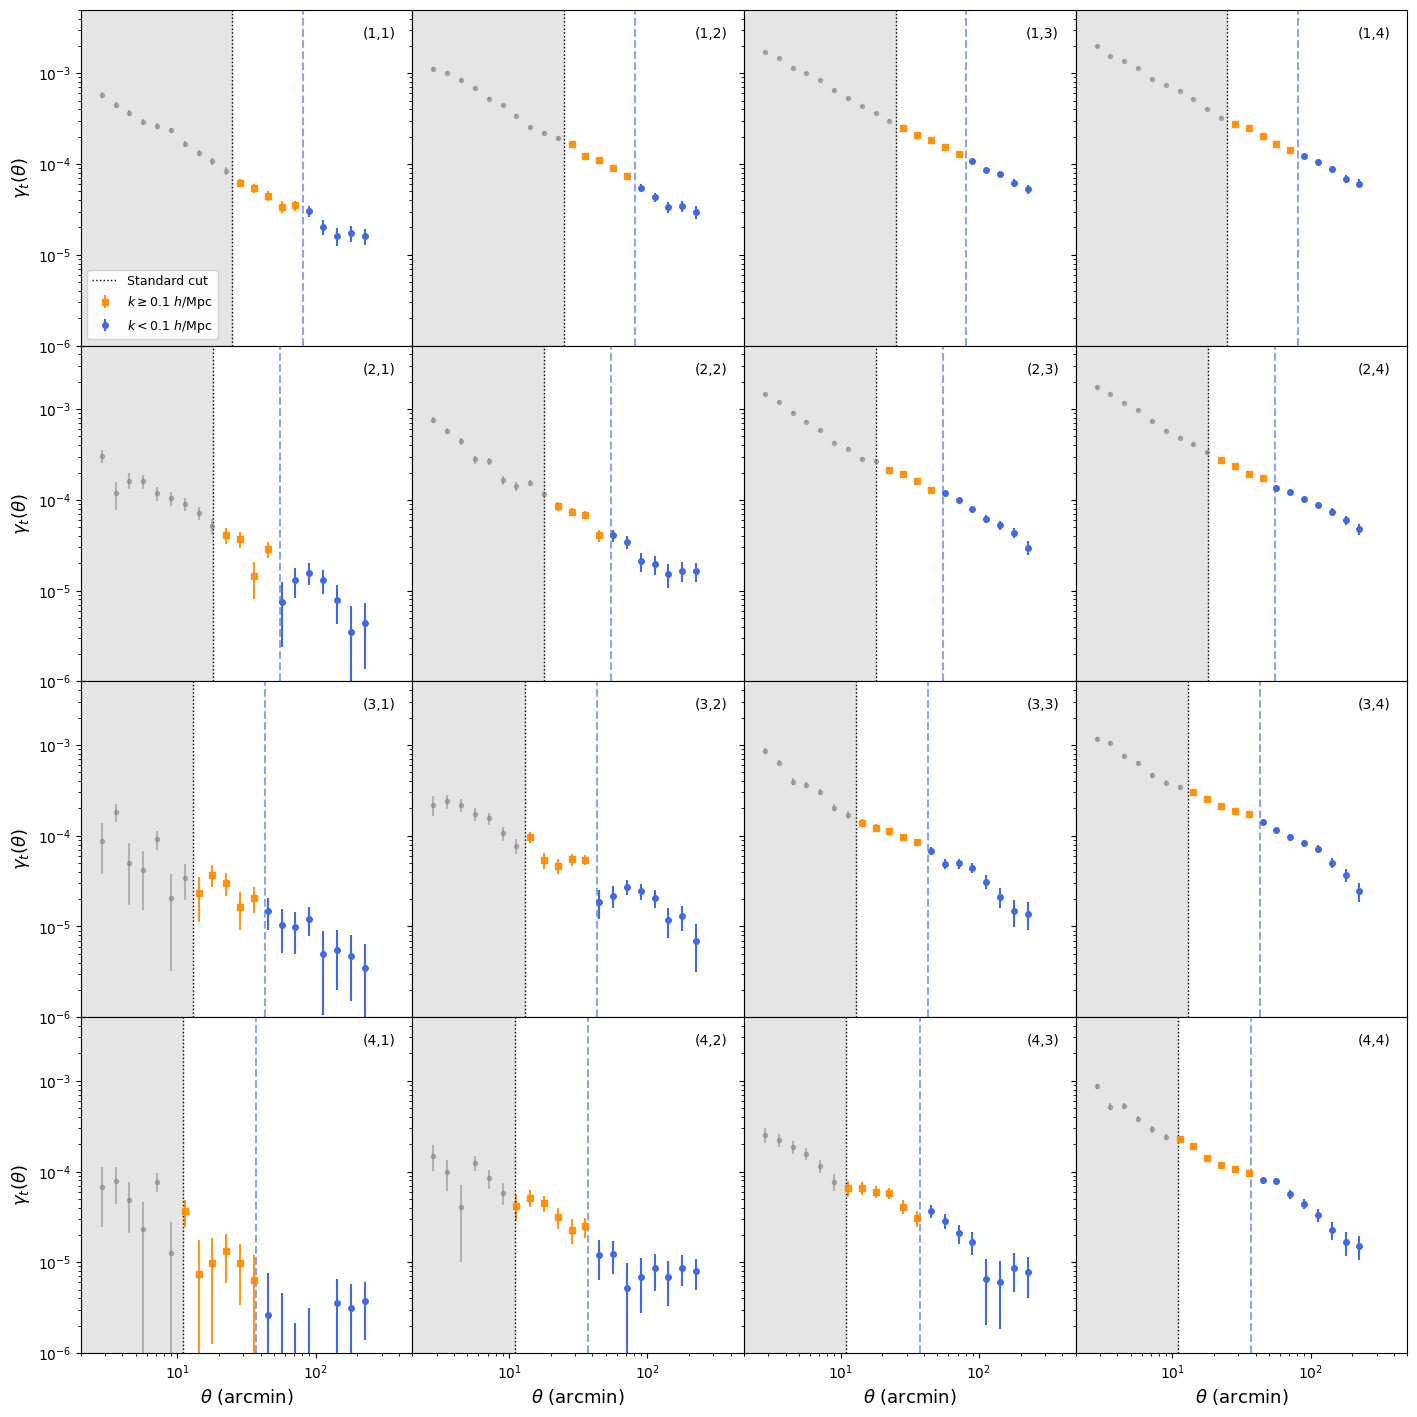

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 数据准备 ---
gammat = hdul['gammat'].data
cov = hdul['COVMAT'].data

start = 400
end = 400 + 480
cov_g = cov[start:end, start:end]
err = np.sqrt(np.diag(cov_g))

bin1 = gammat['BIN1']
bin2 = gammat['BIN2']
theta = gammat['ANG']
value = gammat['VALUE']

cut_matrix_standard = [
    [25, 25, 25, 25],
    [18, 18, 18, 18],
    [13, 13, 13, 13],
    [11, 11, 11, 11]
]

# --- 2. 物理标度切分定义 ---
k_split = 0.05
# 请替换为你 Cosmosis 脚本中实际使用的透镜红移区间对应的共动距离 (Mpc/h)
lens_chis = [850.0, 1250.0, 1600.0, 1850.0] 

# --- 3. 开始绘图 ---
fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=False, sharey=False,
    gridspec_kw={'wspace': 0, 'hspace': 0}
)

for i in range(4):
    for j in range(4):
        ax = axes[i][j]
        b1 = i + 1  # 透镜 Bin (Lens)
        b2 = j + 1  # 源 Bin (Source)

        mask = (bin1 == b1) & (bin2 == b2)
        idx = np.where(mask)[0]

        th = theta[mask]
        val = value[mask]
        sigma = err[idx]

        std_cut = cut_matrix_standard[i][j]

        # 计算该透镜 Bin 对应的 k=0.1 分界角度 theta_split
        theta_split = (180.0 * 60.0 / np.pi) / (k_split * lens_chis[i])

        # ===== 分类掩码 =====
        mask_cut = th < std_cut                                      # Standard cut 去掉的数据
        mask_high_k = (th >= std_cut) & (th <= theta_split)          # 保留的数据：小尺度 (k >= 0.1)
        mask_low_k = (th >= std_cut) & (th > theta_split)            # 保留的数据：大尺度 (k < 0.1)

        # ===== 画点 =====
        # 1. 画被切掉的数据 (灰色圆点，半透明)
        ax.errorbar(th[mask_cut], val[mask_cut], yerr=sigma[mask_cut],
                    fmt='o', color='gray', ms=3, alpha=0.5)

        # 2. 画高 k 数据 (橙色方块)
        ax.errorbar(th[mask_high_k], val[mask_high_k], yerr=sigma[mask_high_k],
                    fmt='s', color='darkorange', ms=4, alpha=0.9,
                    label=r'$k \geq 0.1\ h/{\rm Mpc}$' if (i==0 and j==0) else "")

        # 3. 画低 k 数据 (蓝色圆点)
        ax.errorbar(th[mask_low_k], val[mask_low_k], yerr=sigma[mask_low_k],
                    fmt='o', color='royalblue', ms=4,
                    label=r'$k < 0.1\ h/{\rm Mpc}$' if (i==0 and j==0) else "")

        # ===== 画区域和分割线 =====
        ax.axvspan(0, std_cut, color='gray', alpha=0.2)
        ax.axvline(std_cut, color='black', ls=':', lw=1, label='Standard cut' if (i==0 and j==0) else "")
        ax.axvline(theta_split, color='royalblue', ls='--', lw=1.5, alpha=0.6)

        # ===== 图形设置 =====
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(2, 500)
        ax.set_ylim(1e-6, 5e-3)

        ax.text(
            0.95, 0.95,
            f"({b1},{b2})",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=10
        )

        if j == 0:
            ax.set_ylabel(r'$\gamma_t(\theta)$', fontsize=13)
        else:
            ax.set_yticklabels([])

        if i == 3:
            ax.set_xlabel(r'$\theta\ (\mathrm{arcmin})$', fontsize=13)
        else:
            ax.set_xticklabels([])
            
        # 在第一个子图加上图例
        if i == 0 and j == 0:
            ax.legend(loc='lower left', fontsize=9, framealpha=0.9)

plt.tight_layout(pad=0.1)
plt.show()

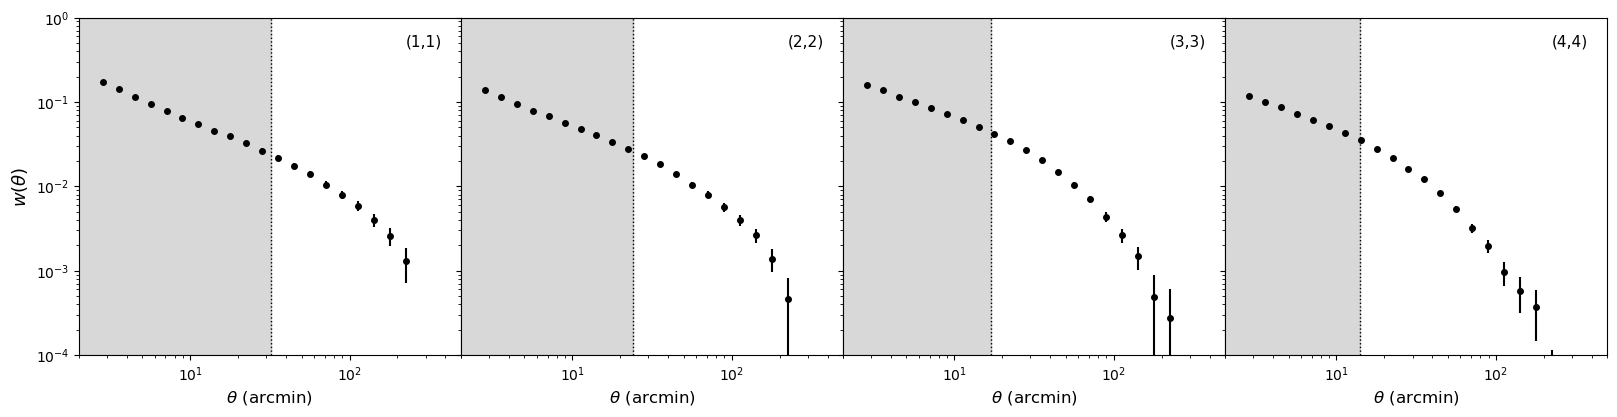

In [44]:
wtheta = hdul['wtheta'].data
cov = hdul['COVMAT'].data

start = 880
end = 1000
cov_w = cov[start:end, start:end]
err = np.sqrt(np.diag(cov_w))

bin1 = wtheta['BIN1']
bin2 = wtheta['BIN2']
theta = wtheta['ANG']
value = wtheta['VALUE']

bins_to_plot = [1, 2, 3, 4]
cut = [32,24,17,14]

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 4),
    sharex=False, sharey=False,
    gridspec_kw={'wspace': 0}
)

for i, b in enumerate(bins_to_plot):
    ax = axes[i]
    mask = (bin1 == b) & (bin2 == b)
    idx = np.where(mask)[0]
    sigma = err[idx]

    ax.errorbar(
        theta[mask], value[mask],
        yerr=sigma,
        fmt='o', color='black', ms=4, label='Standard Data'
    )

    # log-log
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(2, 500)
    ax.set_ylim(1e-4, 1)

    ax.text(
        0.95, 0.95,
        f"({b},{b})",
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=11
    )
    ax.axvspan(0, cut[i], color='gray', alpha=0.3)
    ax.axvline(cut[i], color='black', ls=':', lw=1, label='Standard cut')

    if i == 0:
        ax.set_ylabel(r'$w(\theta)$', fontsize=13)
    else:
        ax.set_yticklabels([])

    ax.set_xlabel(r'$\theta\ (\mathrm{arcmin})$', fontsize=12)

plt.tight_layout(pad=0.1) 
plt.show()


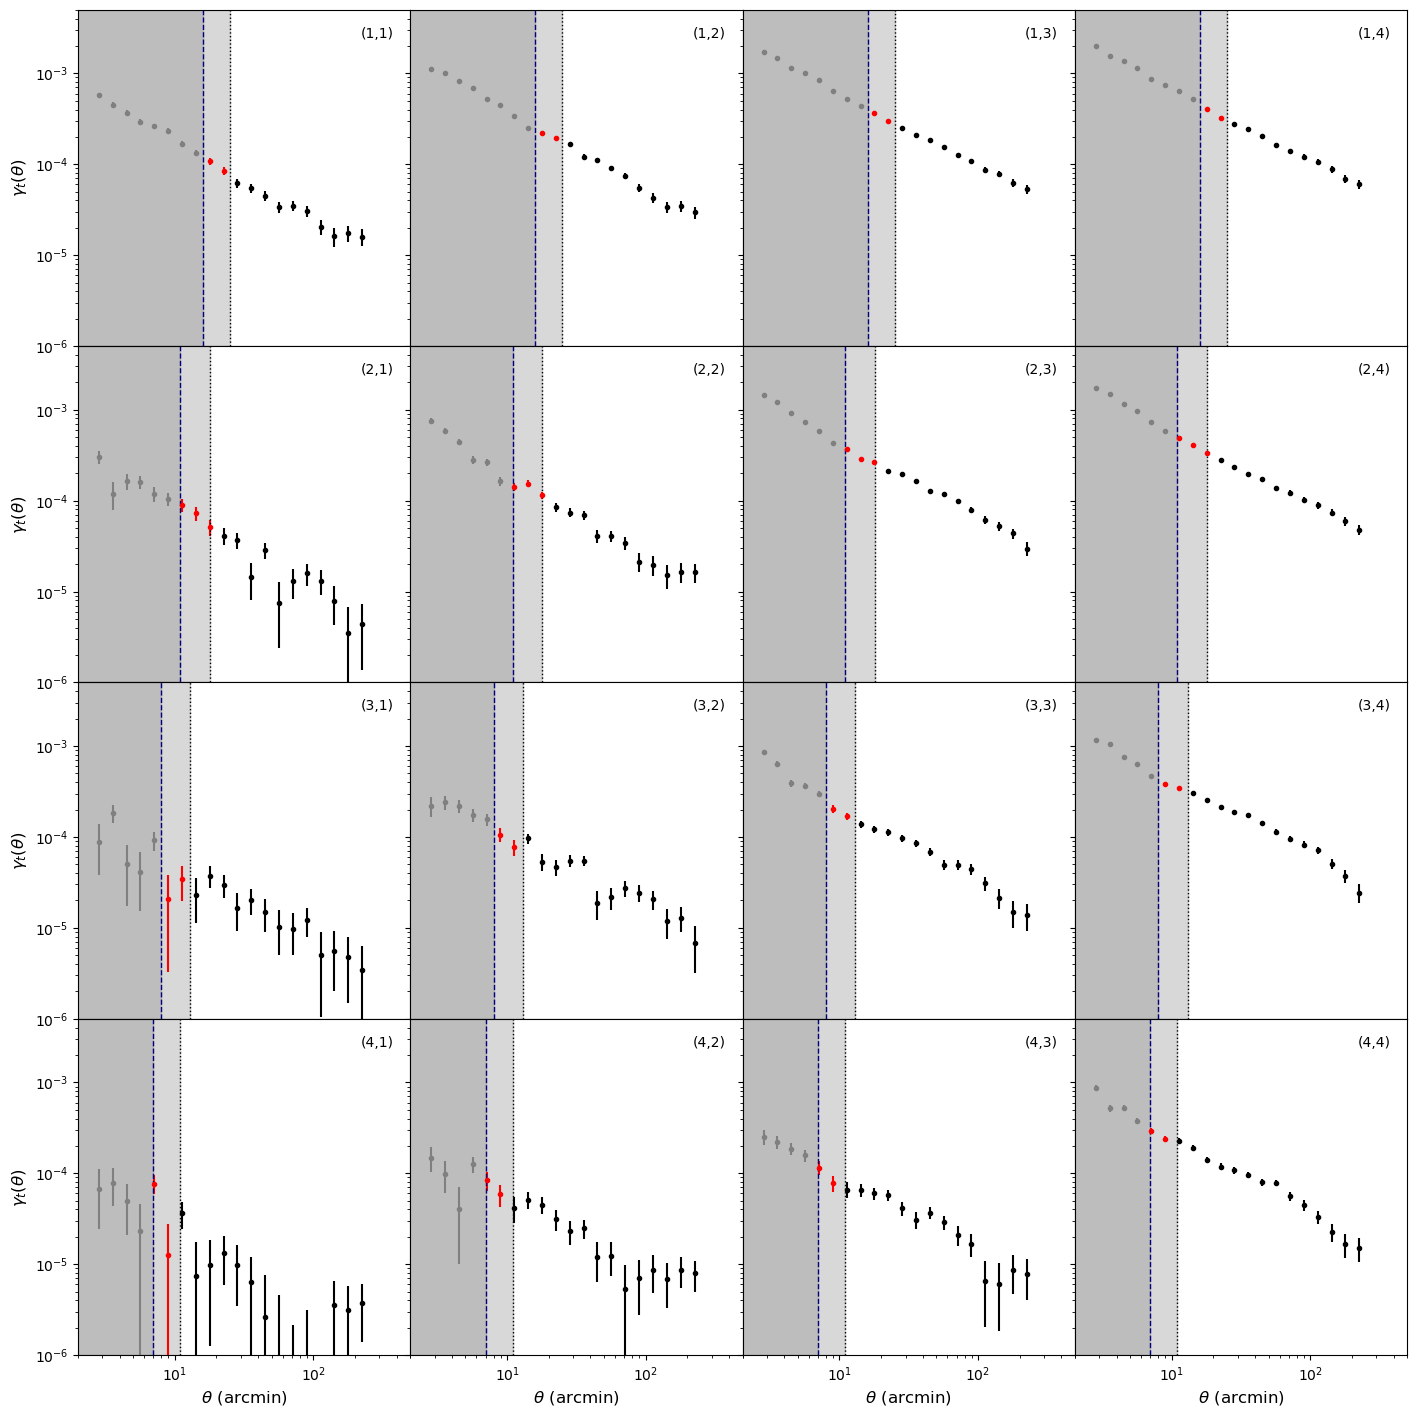

In [48]:
gammat = hdul['gammat'].data
cov = hdul['COVMAT'].data

# 提取 gammat 的协方差
start = 400
end = 400 + 480
cov_g = cov[start:end, start:end]
err = np.sqrt(np.diag(cov_g))

bin1 = gammat['BIN1']
bin2 = gammat['BIN2']
theta = gammat['ANG']
value = gammat['VALUE']

cut_matrix_standard = [
    [25, 25, 25, 25],
    [18, 18, 18, 18],
    [13, 13, 13, 13],
    [11, 11, 11, 11]
]

cut_matrix_radical = [
    [16, 16, 16, 16],
    [11, 11, 11, 11],
    [8, 8, 8, 8],
    [7, 7, 7, 7]
]


fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=False, sharey=False,
    gridspec_kw={'wspace': 0, 'hspace': 0}
)

for i in range(4):
    for j in range(4):
        ax = axes[i][j]
        b1 = i + 1
        b2 = j + 1

        mask = (bin1 == b1) & (bin2 == b2)
        idx = np.where(mask)[0]

        th = theta[mask]
        val = value[mask]
        sigma = err[idx]

        std_cut = cut_matrix_standard[i][j]
        rad_cut = cut_matrix_radical[i][j]

        # ===== 分类掩码 =====
        mask_gray = th < rad_cut                            # radical cut 去掉
        mask_red = (th >= rad_cut) & (th < std_cut)         # radical 去掉、standard 保留
        mask_black = th >= std_cut                          # 完全保留

        # ===== 画点 =====
        ax.errorbar(th[mask_black], val[mask_black], yerr=sigma[mask_black],
                    fmt='o', color='black', ms=3)

        ax.errorbar(th[mask_red], val[mask_red], yerr=sigma[mask_red],
                    fmt='o', color='red', ms=3)

        ax.errorbar(th[mask_gray], val[mask_gray], yerr=sigma[mask_gray],
                    fmt='o', color='gray', ms=3)

        # ===== 画 shaded region（保持你的设置） =====
        ax.axvspan(0, std_cut, color='gray', alpha=0.3, label='Standard cut')
        ax.axvspan(0, rad_cut, color='gray', alpha=0.3, label='Radical cut')
        # ax.axvspan(rad_cut, std_cut, color='navajowhite', alpha=0.4, label='Extended Analysis Region')
        ax.axvline(std_cut, color='black', ls=':', lw=1, label='Standard cut')
        ax.axvline(rad_cut, color='navy', ls='--', lw=1, label='Radical cut')
        # ===== 图形设置 =====
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(2, 500)
        ax.set_ylim(1e-6, 5e-3)

        ax.text(
            0.95, 0.95,
            f"({b1},{b2})",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=10
        )

        if j == 0:
            ax.set_ylabel(r'$\gamma_t(\theta)$', fontsize=12)
        else:
            ax.set_yticklabels([])

        if i == 3:
            ax.set_xlabel(r'$\theta\ (\mathrm{arcmin})$', fontsize=12)
        else:
            ax.set_xticklabels([])

plt.tight_layout(pad=0.1)
plt.show()


绘图完成！图片已保存为 cosmo_plot.png


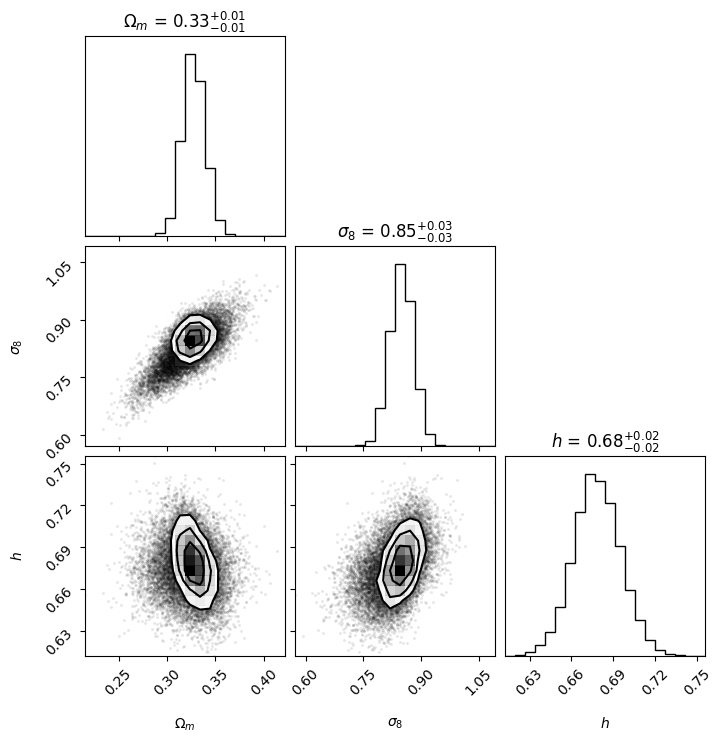

In [ ]:
import corner
import numpy as np
import matplotlib.pyplot as plt

## 1. 修改这里 ##
filename = 'chains/des-y3-maglim-2x2pt-polychord_prior_opt.txt'


## 2. 下面的代码通常不需要修改 ##

# 用numpy读取数据文件，跳过第一行（#开头的注释）
# CosmoSIS输出的最后几列是统计量，我们先读进来
# weight 在倒数第1列, like 在倒数第2列, post 在倒数第3列
all_data = np.loadtxt(filename, skiprows=1)

# 提取权重列（倒数第1列，索引是-1）
# 对于PolyChord/MultiNest的输出，权重至关重要！
weights = all_data[:, -1]

# 选择你想画的参数所在的列
#   第 1 列 (索引 0) -> omega_m
#   第 32 列 (索引 31) -> sigma_8
#   第 2 列 (索引 1) -> h0
columns_to_plot = all_data[:, [0, 31, 1]]

# 为这几个参数创建标签
labels = [r"$\Omega_m$", r"$\sigma_8$", r"$h$"]


## 3. 绘图和保存 ##

# 一行命令生成漂亮的图！
fig = corner.corner(
    columns_to_plot,
    labels=labels,
    weights=weights,
    show_titles=True, # 在图上显示每个参数的数值结果
    title_kwargs={"fontsize": 12}
)

# 保存图像
plt.savefig("cosmo_plot.png", dpi=200) # 保存为PNG图片

print("绘图完成！图片已保存为 cosmo_plot.png")

# 显示图像
plt.show()



预测的1-sigma误差:
[6.60859230e-02 2.81612351e-01 2.73144854e-02 3.44065042e-01
 2.00763505e-09 9.07537227e-03 7.71528959e-03 7.31813741e-03
 7.32336918e-03 1.37189427e-02 9.51160495e-03 7.91883151e-03
 1.48854012e-02 1.20390345e-01 9.32294904e+12 6.00077567e-03
 8.78061215e-03 5.72060892e-03 5.87895926e-03 5.58267234e-02
 8.48573576e-02 5.26854817e-02 5.00516776e-02 4.12723385e-02
 5.09792475e-02 6.06829732e-02 6.99920851e-02 7.19507103e-01
 1.15594573e-01 1.41785507e-01 1.28416046e-01 1.25315609e-01]


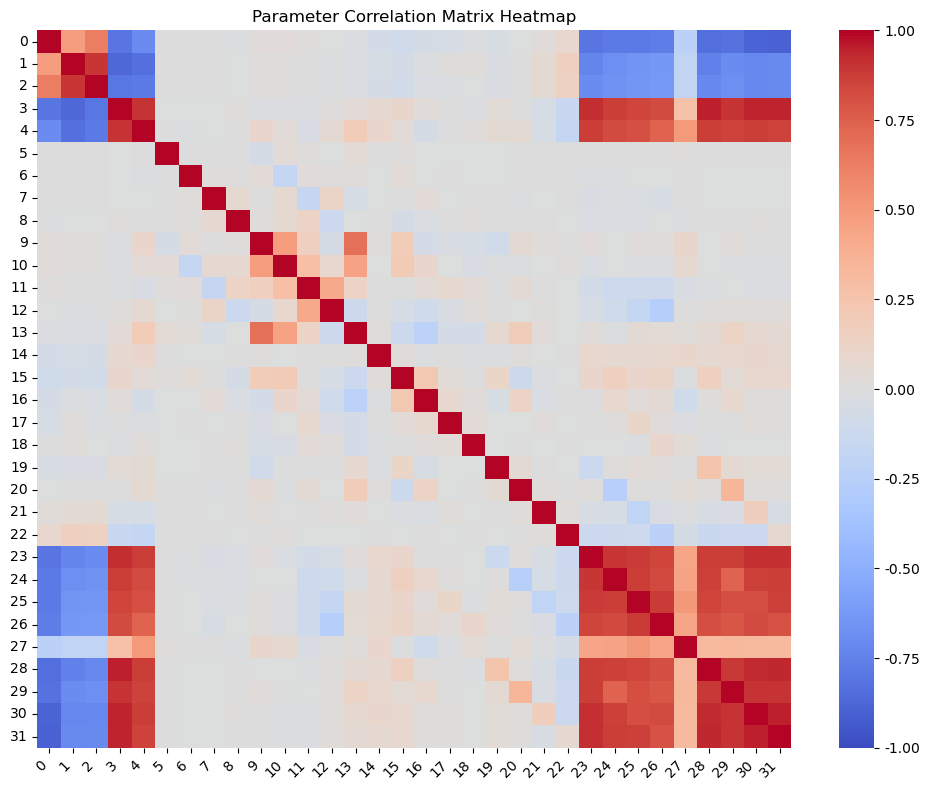

In [52]:
import numpy as np

# 1. 读取你的Fisher矩阵文件
F = np.loadtxt('My_test_fisher.txt') 

# 2. 计算逆矩阵，也就是参数的协方差矩阵 C
# 使用 np.linalg.inv() 来求逆

C = np.linalg.inv(F)

# 3. 从协方差矩阵 C 中提取信息
# 对角线元素的平方根就是每个参数的 1-sigma 误差预测
parameter_errors = np.sqrt(np.diag(C))

# 打印出每个参数的预测误差
# (假设你已经有了按顺序排列的参数名列表 a_sorted_parameter_list)
# for i, param_name in enumerate(a_sorted_parameter_list):
#     print(f"参数 '{param_name}' 的预测误差 (1-sigma): {parameter_errors[i]}")

print("预测的1-sigma误差:")
print(parameter_errors)

# 计算相关系数矩阵 (Correlation Matrix)
correlation_matrix = np.zeros_like(C)
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        correlation_matrix[i, j] = C[i, j] / np.sqrt(C[i, i] * C[j, j])

plt.figure(figsize=(10, 8)) # 调整图像大小

import seaborn as sns

sns.heatmap(
    correlation_matrix,
    annot=False, # 如果矩阵不大（比如<10x10），可以设为 True 来显示数字
    cmap='coolwarm', # 一个很好的蓝-白-红颜色方案
    vmin=-1, vmax=1 # 确保颜色条范围是 -1 到 1
)

plt.title('Parameter Correlation Matrix Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() # 调整布局防止标签重叠
plt.show()


协方差矩阵...
子协方差矩阵...
正在生成样本并绘制三角图...
Removed no burn in


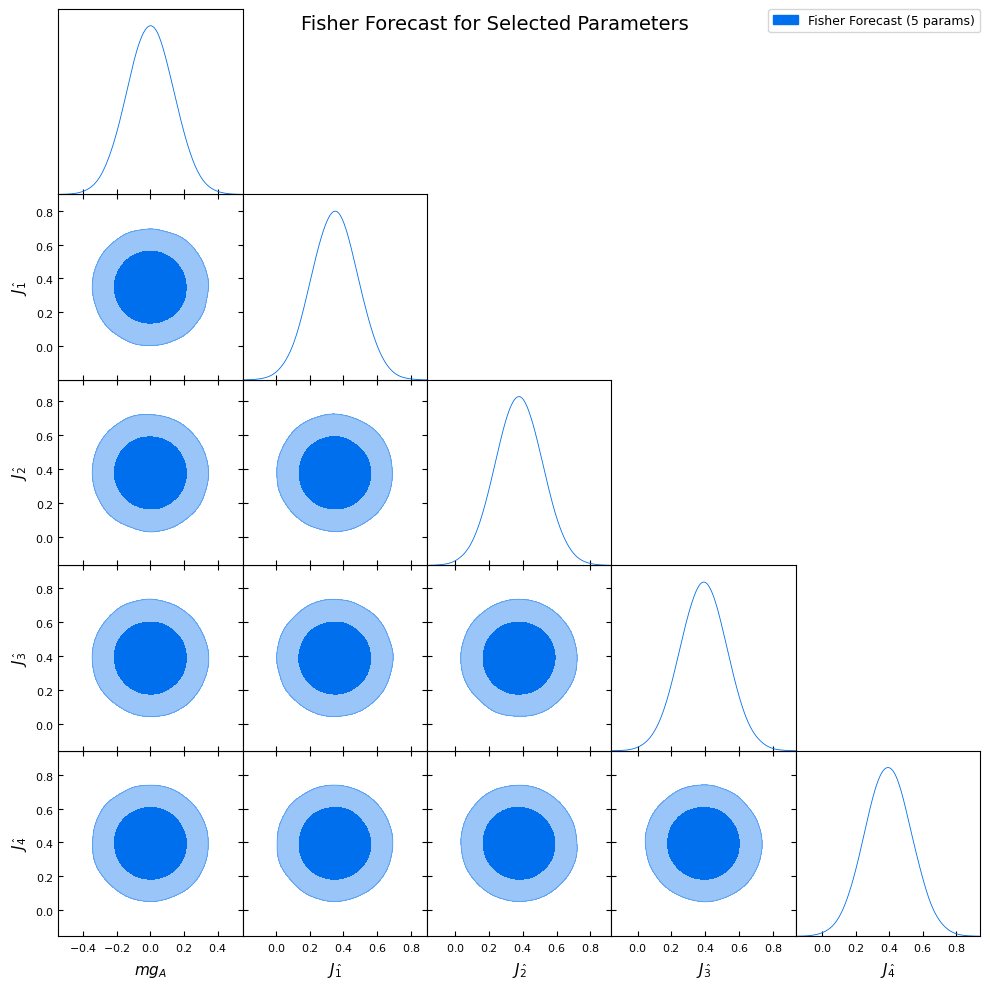


所选参数的边缘化误差:
mg_A: 0.0000 ± 0.1405
J_bin_bias--jhat1: 0.3481 ± 0.1407
J_bin_bias--jhat2: 0.3771 ± 0.1407
J_bin_bias--jhat3: 0.3903 ± 0.1407
J_bin_bias--jhat4: 0.3938 ± 0.1408


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# --- 1. 数据准备 ---

np.random.seed(123)
_F_dummy = np.random.rand(32, 32)
F = (_F_dummy + _F_dummy.T) / 2 + np.eye(32) * 50 # 确保对称且可逆


# --- 完整参数列表 (必须与F的行列顺序完全一致!) ---
# 从你的文件'fisher_matrix.txt'的第一行解析得到
full_names = [
    'cosmological_parameters--omega_m', 'cosmological_parameters--h0', 'cosmological_parameters--omega_b',
    'cosmological_parameters--n_s', 'cosmological_parameters--a_s', 'shear_calibration_parameters--m1',
    'shear_calibration_parameters--m2', 'shear_calibration_parameters--m3', 'shear_calibration_parameters--m4',
    'wl_photoz_errors--bias_1', 'wl_photoz_errors--bias_2', 'wl_photoz_errors--bias_3',
    'wl_photoz_errors--bias_4', 'intrinsic_alignment_parameters--a', 'intrinsic_alignment_parameters--alpha',
    'lens_photoz_errors--bias_1', 'lens_photoz_errors--bias_2', 'lens_photoz_errors--bias_3',
    'lens_photoz_errors--bias_4', 'lens_photoz_errors--width_1', 'lens_photoz_errors--width_2',
    'lens_photoz_errors--width_3', 'lens_photoz_errors--width_4', 'mg_A', 'J_bin_bias--jhat1',
    'J_bin_bias--jhat2', 'J_bin_bias--jhat3', 'J_bin_bias--jhat4', 'b_bin_bias--bhat1',
    'b_bin_bias--bhat2', 'b_bin_bias--bhat3', 'b_bin_bias--bhat4'
]

# 完整的 31 个参数中心值 (从文件 mu_0, mu_1... 处获得)
full_means = np.array([
    0.3166, 0.6727, 0.0494116, 0.9649, 2.101e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.34809782, 0.37706263, 0.39029051,
    0.39378215, 1.0418395, 1.14332584, 1.05551404, 1.03908743
])


# --- 2. 选择你想要绘制的参数 ---
# 在这里列出你感兴趣的参数的名称
params_to_plot = [
'mg_A', 
'J_bin_bias--jhat1',
'J_bin_bias--jhat2', 
'J_bin_bias--jhat3', 
'J_bin_bias--jhat4'
]

# 找到这些参数在完整列表中的索引
indices_to_plot = [full_names.index(p) for p in params_to_plot]

# 提取这些参数的中心值和用于画图的标签
sub_means = full_means[indices_to_plot]
sub_names = [full_names[i] for i in indices_to_plot]
sub_labels = [r'mg_A', r'J_{\hat{1}}', r'J_{\hat{2}}', r'J_{\hat{3}}', r'J_{\hat{4}}'] # 手动为子集提供LaTeX标签


# --- 3. 核心计算：先求全逆，再取子集 ---
print("协方差矩阵...")
full_cov_matrix = np.linalg.inv(F)

print("子协方差矩阵...")
# 使用 np.ix_ 来优雅地提取子矩阵
sub_cov_matrix = full_cov_matrix[np.ix_(indices_to_plot, indices_to_plot)]


# --- 4. 使用 getdist 画图 ---
print("正在生成样本并绘制三角图...")

# 从子集的均值和协方差矩阵创建 getdist 样本对象
samples = MCSamples(
    samples=np.random.multivariate_normal(sub_means, sub_cov_matrix, size=200000),
    names=sub_names,
    labels=sub_labels,
    label='Forecast Subset'
)

# 创建一个画图对象
g = plots.get_subplot_plotter()

# 绘制三角图
g.triangle_plot(
    [samples],
    filled=True,
    legend_labels=['Fisher Forecast (5 params)'],
    legend_loc='upper right',
    # 可以为子集中的参数设置坐标轴范围
    param_limits={ 
        'cosmological_parameters--omega_m': (
            sub_means[0] - 5*np.sqrt(sub_cov_matrix[0,0]),
            sub_means[0] + 5*np.sqrt(sub_cov_matrix[0,0])
        )
    }
)

plt.suptitle('Fisher Forecast for Selected Parameters', fontsize=14)
plt.show()

# (可选) 打印出子矩阵的误差，以验证
errors = np.sqrt(np.diag(sub_cov_matrix))
print("\n所选参数的边缘化误差:")
for i, name in enumerate(sub_names):
    print(f"{name}: {sub_means[i]:.4f} ± {errors[i]:.4f}")


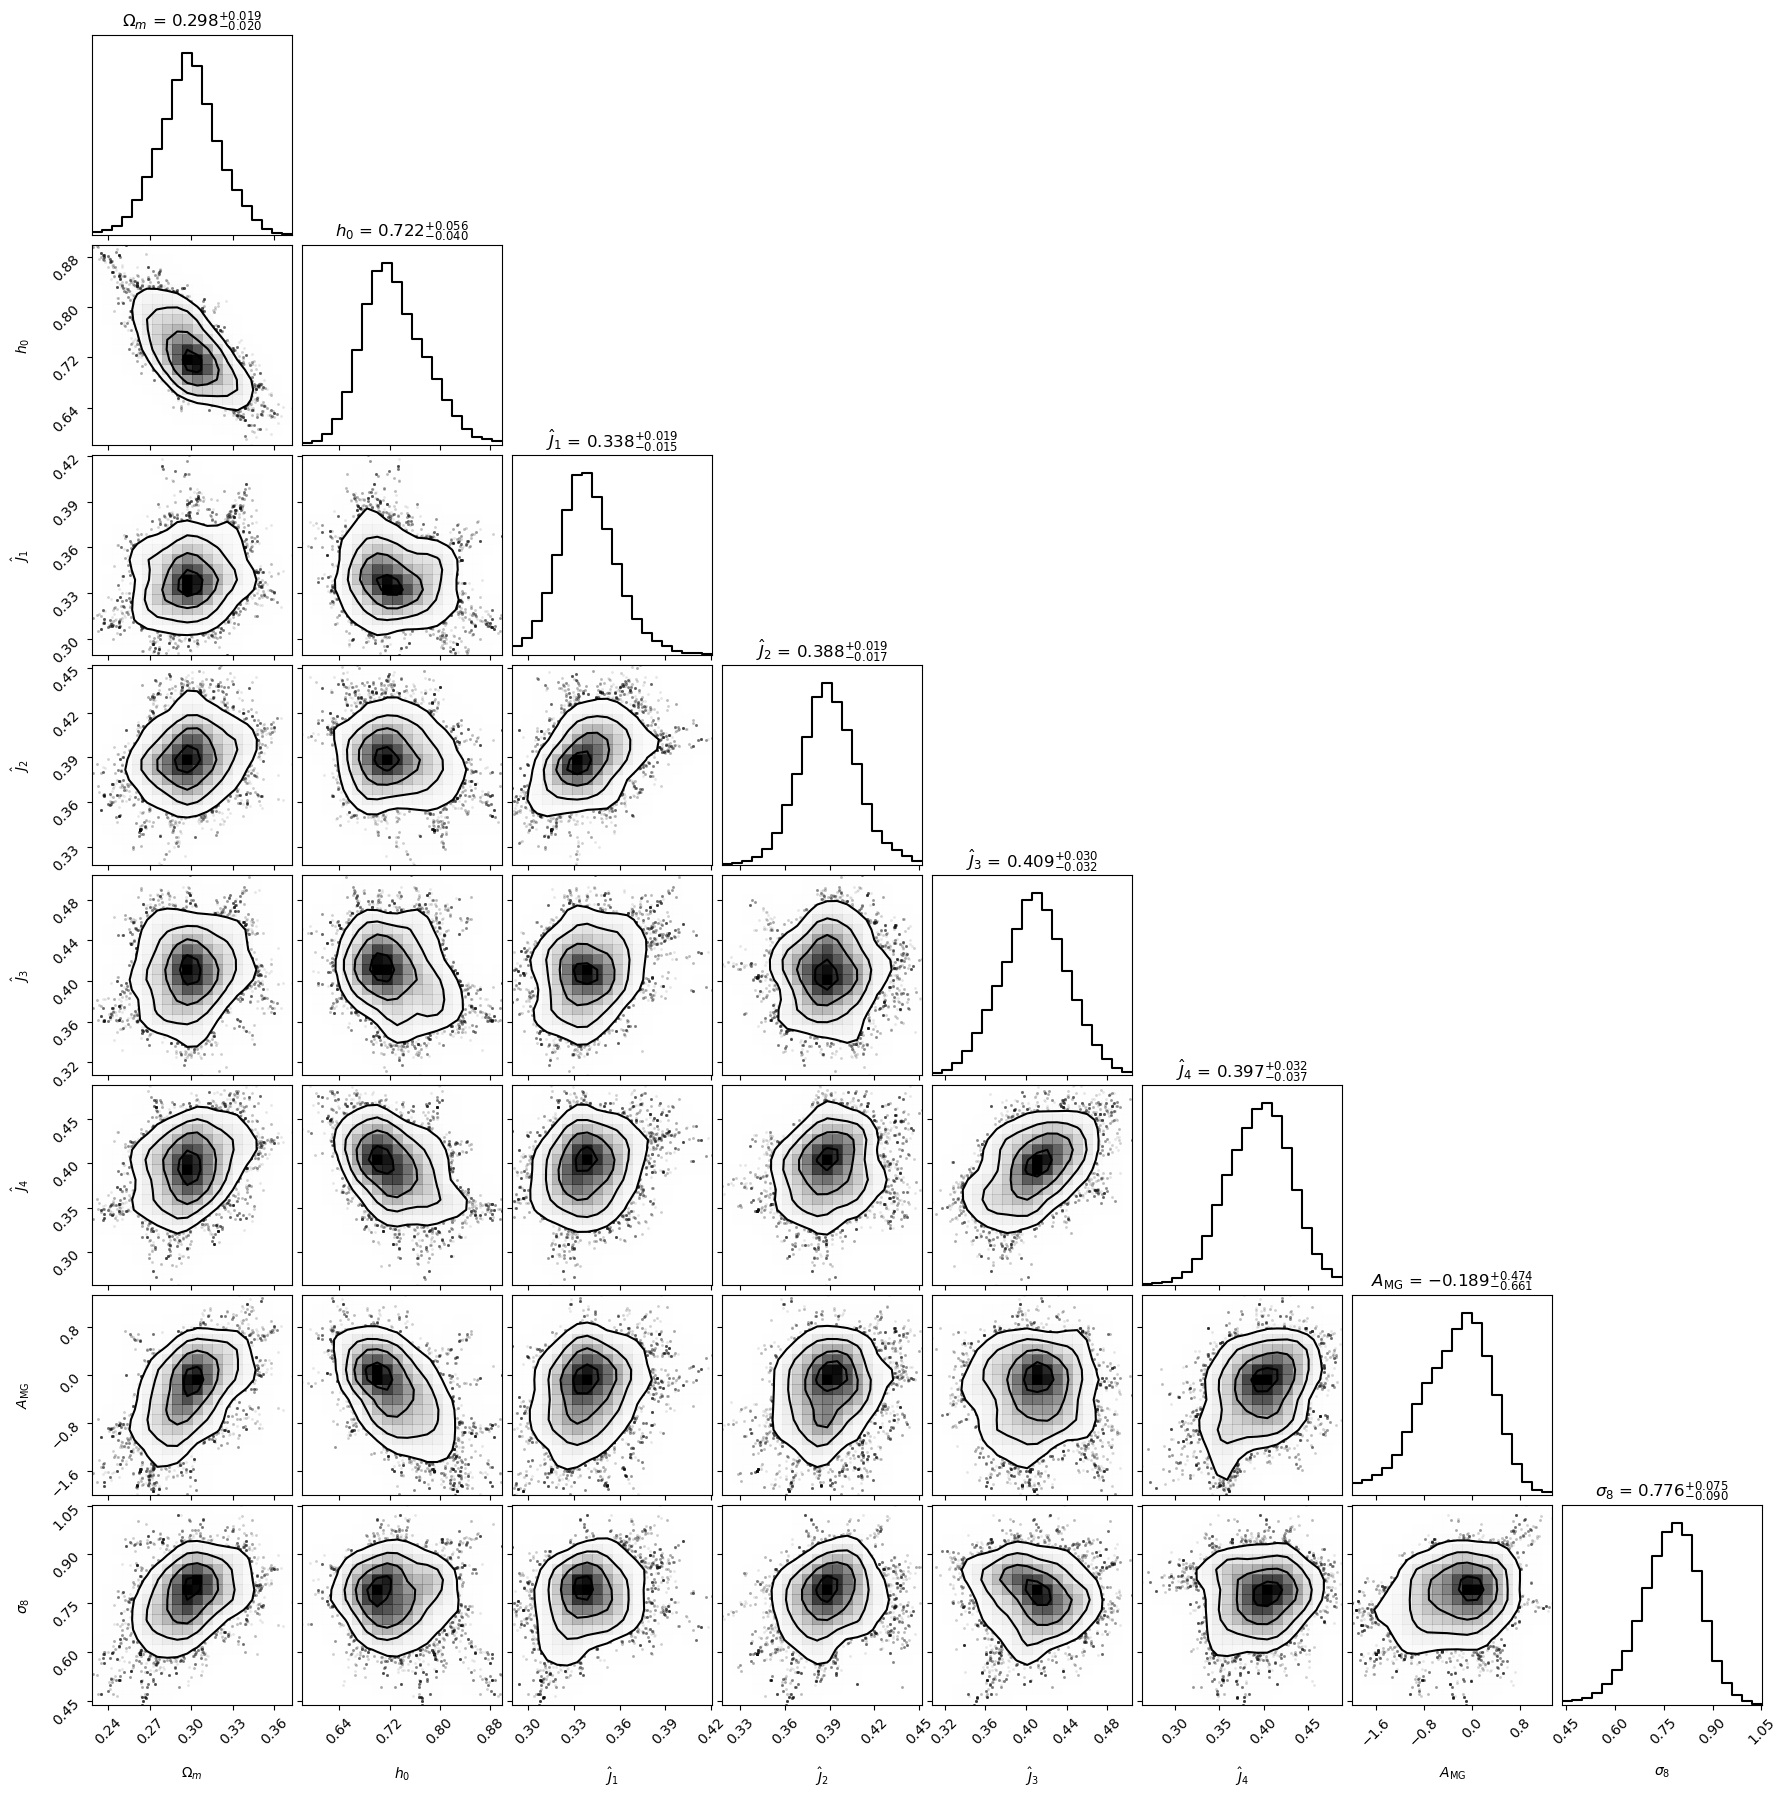

In [2]:
import corner
import numpy as np
import matplotlib.pyplot as plt


filename = '/home/wzx/WorkWork/cosmosis_weyl/MyTest/Mychain_first_standard.txt'
# === 1. 读取链 ===
all_data = np.loadtxt(filename, skiprows=1)

# === 2. 去 burn-in ===
burnin = int(0.5 * len(all_data))
data = all_data[burnin:]

# === 3. 提取需要绘制的参数列 ===
cols = [0, 1, 23, 24, 25, 26, 27, 32]
columns_to_plot = data[:, cols]

labels = [
    r"$\Omega_m$", r"$h_0$", r"$\hat{J}_1$", r"$\hat{J}_2$", 
    r"$\hat{J}_3$", r"$\hat{J}_4$", r"$A_\text{MG}$", r"$\sigma_8$"
]

fig = corner.corner(
    columns_to_plot,
    labels=labels,
    show_titles=True, # 在图上显示每个参数的数值结果
    title_fmt=".3f", 
    title_kwargs={"fontsize": 12},
    smooth=1,
    smooth1d=1
)

# 显示图像
plt.show()



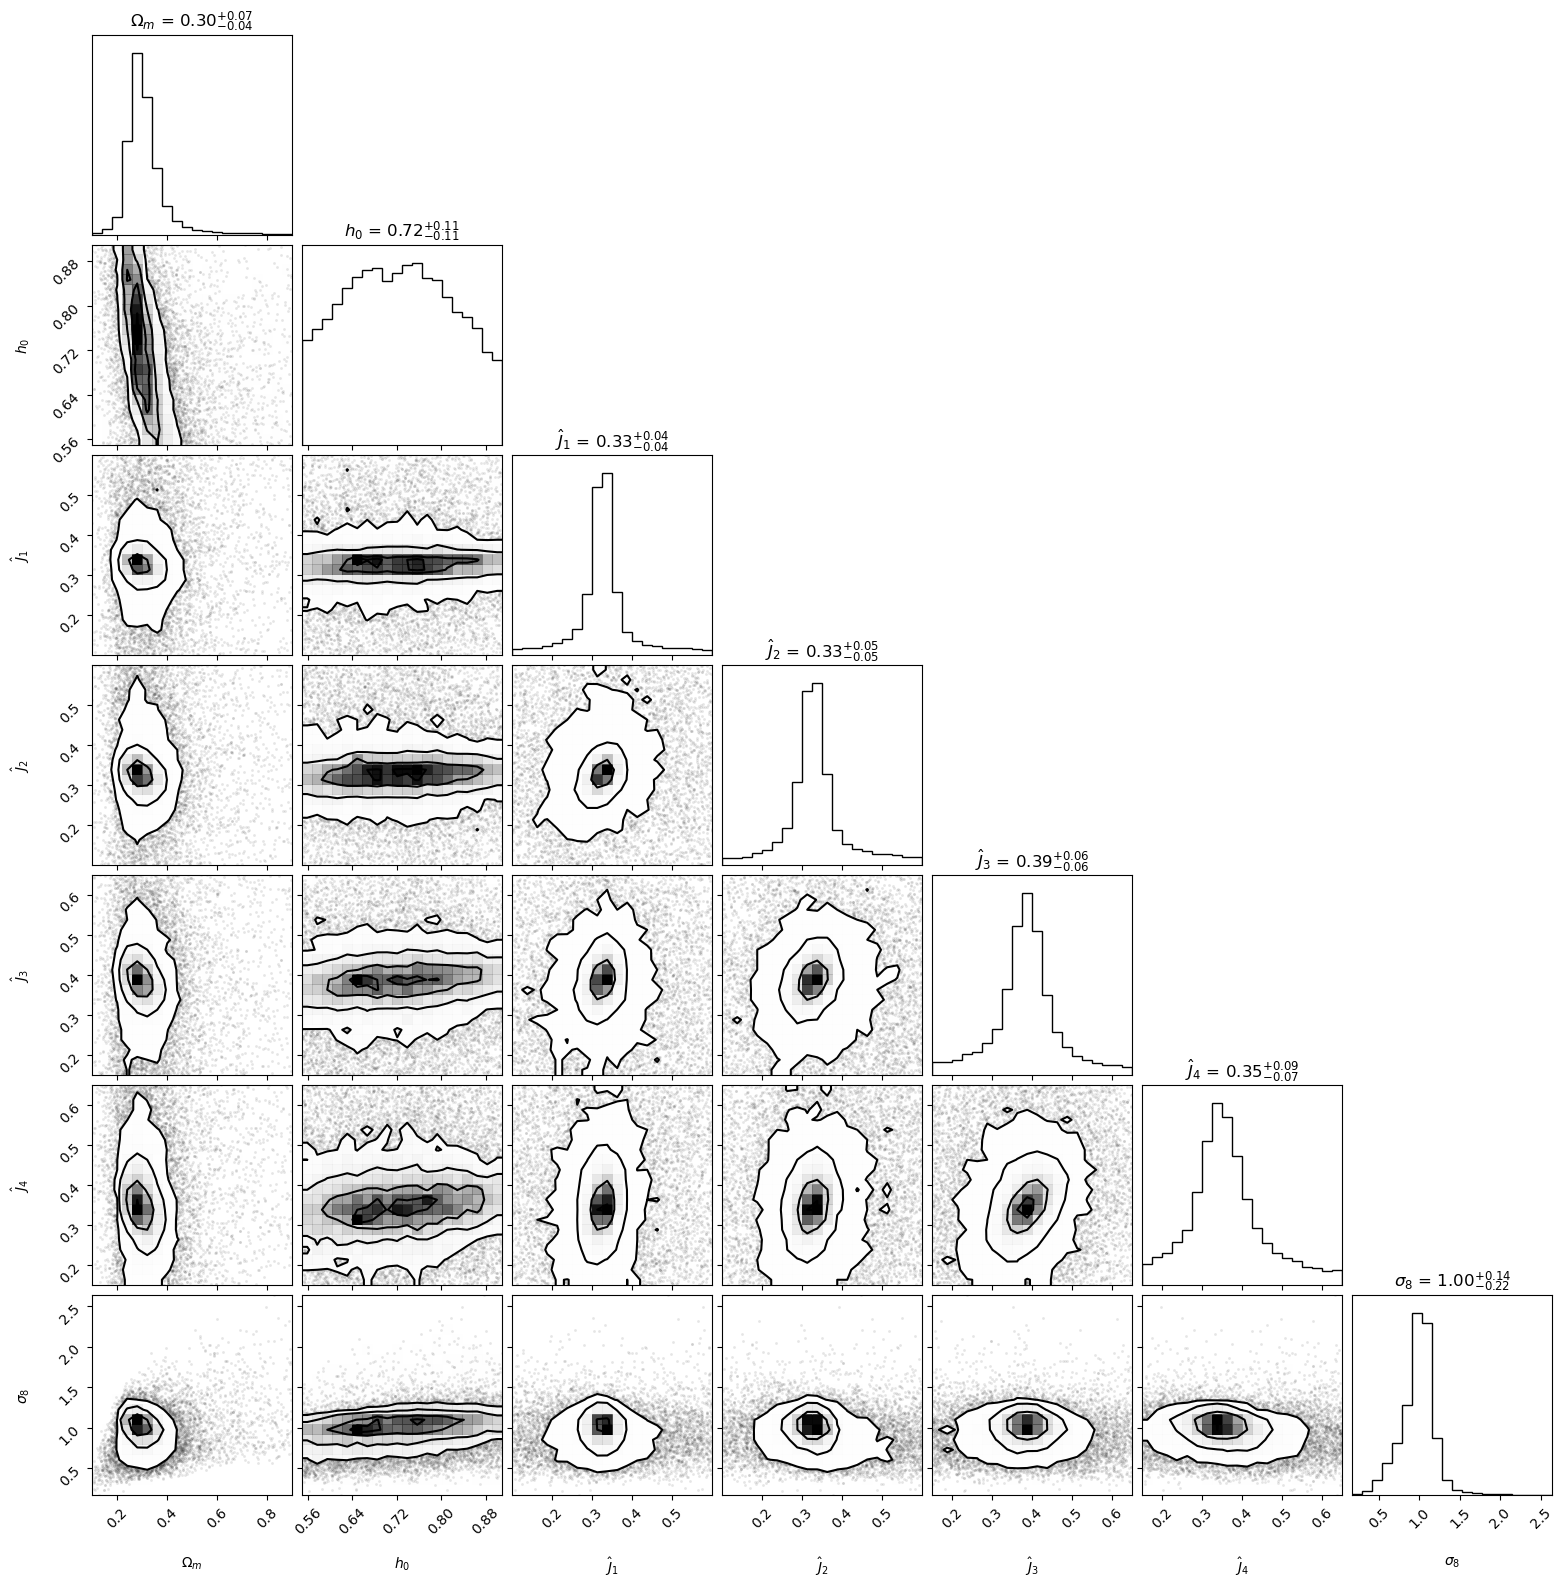

In [125]:
import corner
import numpy as np
import matplotlib.pyplot as plt

# filename = 'Mychain_NoScaleCut.txt'
filename = '/home/wzx/WorkWork/cosmosis_weyl/chains/des-y3-maglim-2x2pt-polychord_noprior_opt.txt'

all_data = np.loadtxt(filename, skiprows=1)
burnin = int(0.5 * len(all_data))
data = all_data[burnin:]

columns_to_plot = all_data[:, [0, 1, 23, 24, 25, 26, 31]]

labels = [r"$\Omega_m$", r"$h_0$" ,r"$\hat{J}_1$",r"$\hat{J}_2$",r"$\hat{J}_3$",r"$\hat{J}_4$",r"$\sigma_8$"]

fig = corner.corner(
    columns_to_plot,
    labels=labels,
    show_titles=True, # 在图上显示每个参数的数值结果
    title_fmt=".2f", 
    title_kwargs={"fontsize": 12}
)

# 显示图像
plt.show()



In [9]:
import numpy as np
from scipy.integrate import odeint

# ==========================================
# 1. 输入数据 (请根据你的MCMC结果修改这里)
# ==========================================

# 最佳拟合宇宙学参数 (建议取 MCMC 的均值)
Om0 = 0.3166
h = 0.6727

# 红移分箱
z_bins = np.array([0.295, 0.467, 0.626, 0.771])

# 你测量的 Jhat 均值 (Mean)
# J_mean = np.array([0.329, 0.377, 0.406, 0.365]) 
J_mean = np.array([0.327, 0.328, 0.388, 0.345]) 

# !!! 关键：你需要填入 Jhat 的 1-sigma 误差 !!!
# (这里我用了假设值，请替换为你 MCMC 输出的 std dev)
# J_err  = np.array([0.012, 0.015, 0.015, 0.021]) 
J_err  = np.array([0.017, 0.021, 0.032, 0.04]) 

# ==========================================
# 2. 定义计算函数
# ==========================================

def get_Om_z(z, Om0):
    Ez2 = Om0 * (1+z)**3 + (1-Om0)
    return Om0 * (1+z)**3 / Ez2

def compute_growth(z_vals, Om0):
    # 定义微分方程 y = [D, dD/da]
    def growth_ode(y, a, Om0):
        D, dDda = y
        Ez2 = Om0 * a**(-3) + (1-Om0)
        Om_a = Om0 * a**(-3) / Ez2
        dlnHda = -1.5 * Om_a / a
        d2Dda2 = - (3/a + dlnHda) * dDda + 1.5 * Om_a * D / a**2
        return [dDda, d2Dda2]
    
    a_grid = np.linspace(1e-3, 1.0, 1000)
    sol = odeint(growth_ode, [1e-3, 1.0], a_grid, args=(Om0,))
    D_unnorm = sol[:, 0]
    D_norm = D_unnorm / D_unnorm[-1] # D(z=0)=1
    
    a_targets = 1.0 / (1.0 + z_vals)
    return np.interp(a_targets, a_grid, D_norm)

# ==========================================
# 3. 执行计算与误差传递
# ==========================================

# 计算背景和生长因子
Om_z = get_Om_z(z_bins, Om0)
D1_z = compute_growth(z_bins, Om0)

# 转换因子 (Conversion Factor): J -> sigma8
# sigma8 = J / (Om_z * D1_z)
# 令 Factor = 1 / (Om_z * D1_z)
factor = 1.0 / (Om_z * D1_z)

# --- 计算每个 Bin 的 sigma8 及其误差 ---
s8_individual = J_mean * factor
s8_err_individual = J_err * factor  # 线性误差传递

print("-" * 40)
print(f"{'Bin':<5} {'z':<8} {'J_hat':<15} {'Derived sigma8(0)':<20}")
print("-" * 40)
for i in range(4):
    print(f"{i+1:<5} {z_bins[i]:<8.3f} {J_mean[i]:.3f}+/-{J_err[i]:.3f}   {s8_individual[i]:.3f} +/- {s8_err_individual[i]:.3f}")
print("-" * 40)

# ==========================================
# 4. 合并结果 (Inverse Variance Weighting)
# ==========================================
# 原文说 "Combining the four measurements... we can fit for sigma8"
# 这在数学上等价于“加权平均”，权重 w = 1 / error^2

weights = 1.0 / (s8_err_individual**2)
s8_combined_mean = np.sum(weights * s8_individual) / np.sum(weights)
s8_combined_err = np.sqrt( 1.0 / np.sum(weights) )

print(f"\n【最终结果】")
print(f"Combined sigma8(0) = {s8_combined_mean:.3f} ± {s8_combined_err:.3f}")

----------------------------------------
Bin   z        J_hat           Derived sigma8(0)   
----------------------------------------
1     0.295    0.327+/-0.017   0.763 +/- 0.040
2     0.467    0.328+/-0.021   0.707 +/- 0.045
3     0.626    0.388+/-0.032   0.808 +/- 0.067
4     0.771    0.345+/-0.040   0.712 +/- 0.083
----------------------------------------

【最终结果】
Combined sigma8(0) = 0.746 ± 0.026


standard model: σ₈ = 0.803
more dark matter: σ₈ = 0.909
stronger initial perturbations: σ₈ = 0.983


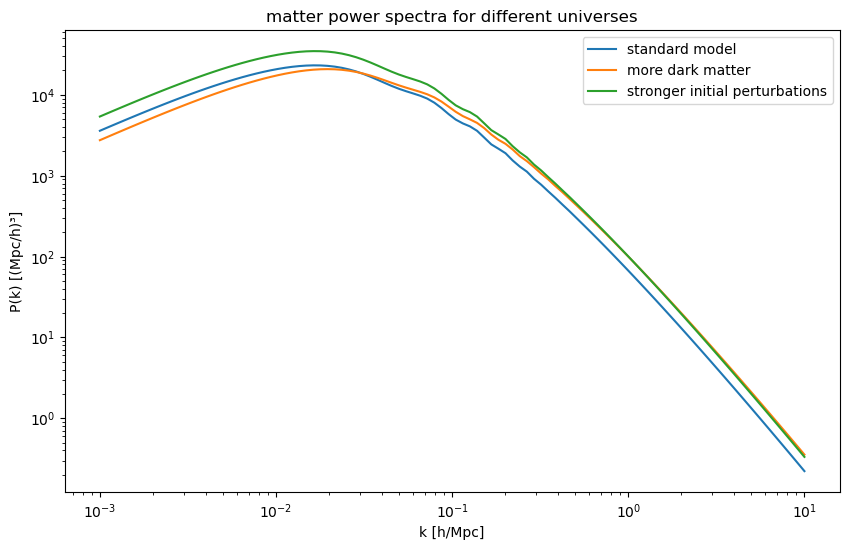

In [3]:
import camb
import matplotlib.pyplot as plt
import numpy as np

def create_universe(H0, ombh2, omch2, As, ns):
    """用给定参数创建一个'宇宙'"""
    pars = camb.CAMBparams()
    
    # 设置宇宙学背景
    pars.set_cosmology(
        H0=H0, ombh2=ombh2, omch2=omch2, 
        mnu=0.06, tau=0.06, omk=0
    )
    
    # 设置初始条件
    pars.InitPower.set_params(As=As, ns=ns)
    
    # 我们想要物质功率谱
    pars.set_matter_power(redshifts=[0], kmax=10.0)
    
    return camb.get_results(pars)

# 创建三个不同的"宇宙"进行比较
cosmos = []

# 宇宙1：标准ΛCDM
cosmos.append(("standard model", create_universe(67.5, 0.022, 0.122, 2e-9, 0.965)))

# 宇宙2：更多暗物质
cosmos.append(("more dark matter", create_universe(67.5, 0.022, 0.150, 2e-9, 0.965)))

# 宇宙3：更强初始扰动
cosmos.append(("stronger initial perturbations", create_universe(67.5, 0.022, 0.122, 3e-9, 0.965)))

# 比较这三个宇宙的物质功率谱
plt.figure(figsize=(10, 6))

for name, results in cosmos:
    kh, z, pk = results.get_matter_power_spectrum(minkh=1e-3, maxkh=10, npoints=100)
    plt.loglog(kh, pk[0], label=name)
    
    # 获取每个宇宙的σ8（结构形成的程度）
    sigma8 = results.get_sigma8()[-1]
    print(f"{name}: σ₈ = {sigma8:.3f}")

plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)³]')
plt.title('matter power spectra for different universes')
plt.legend()
plt.show()

sigma8(0) = [0.80693329]


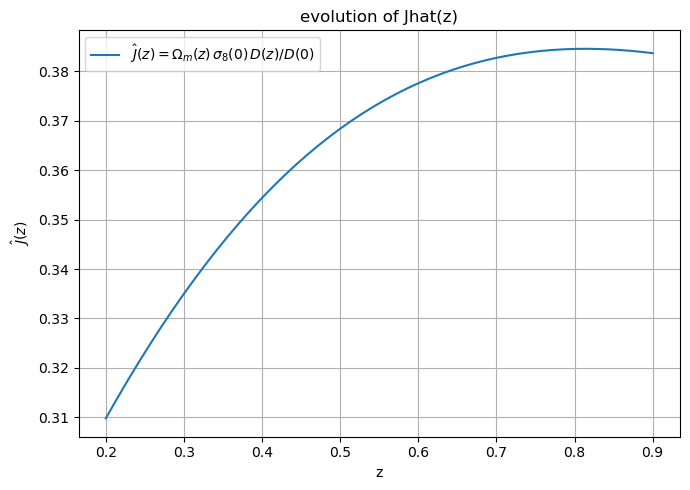

z=0.29: Omega_m=0.4770, D=0.8619, sigma8=0.6955, Jhat=0.3318
z=0.44: Omega_m=0.5627, D=0.7951, sigma8=0.6416, Jhat=0.3610
z=0.59: Omega_m=0.6302, D=0.7404, sigma8=0.5974, Jhat=0.3765
z=0.73: Omega_m=0.6877, D=0.6911, sigma8=0.5577, Jhat=0.3835
z=0.84: Omega_m=0.7269, D=0.6554, sigma8=0.5289, Jhat=0.3844


In [43]:
"""
计算 Jhat(z) = Omega_m(z) * sigma8(0) * D1(z)/D1(0)
使用 CAMB 输出线性 P(k,z) 得到 D1(z)，并用 CAMB 的 get_sigma8() 得到 sigma8(0)。
"""
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb import model

H0 = 68.22
ombh2 = 0.022
omch2 = 0.118
As = 2.1e-9
ns = 0.965

pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)
pars.InitPower.set_params(As=As, ns=ns)

zmax = 0.9
kmax = 1.0  # h/Mpc, 只要包含所选 k_choice 即可

# 要计算线性功率（不启用非线性）
pars.set_matter_power(redshifts=[0.0], kmax=kmax)  # redshifts 参数这里主要用来初始化
results = camb.get_results(pars)

sigma8_0 = results.get_sigma8()  # CAMB 返回的是 z=0 的 sigma8（线性）
print("sigma8(0) =", sigma8_0)

# 4. 构造 P(k,z) 插值器用于计算 D(z)
pk_interp = camb.get_matter_power_interpolator(pars,
                                               nonlinear=False,
                                               kmax=kmax, zmax=zmax,
                                               hubble_units=True, k_hunit=True)

# 选一个小的 k 来代表线性增长（k_choice 应在线性区）
k_choice = 1e-3  # h/Mpc，保守选很小的 k
# 计算 D(z) = sqrt(P(k,z)/P(k,0))，归一化 D(0)=1
zs = np.linspace(0.2, 0.9, 50)
P0 = pk_interp.P(0.0, k_choice)
D = np.array([np.sqrt(pk_interp.P(z, k_choice) / P0) for z in zs])  # D(z)/D(0)

# -------------------------
# 5. 计算 Omega_m(z)
# 先从给定参数计算 Omega_m0
h = H0 / 100.0
Omega_m0 = (ombh2 + omch2) / (h**2)

# 用 CAMB 的 H(z) 获取更精确的 H(z)
Hz_array = np.array([results.hubble_parameter(z) for z in zs])  # 返回 km/s/Mpc
H0_from_results = results.hubble_parameter(0.0)
# Omega_m(z) = Omega_m0 * (1+z)^3 * (H0/H(z))^2
Omega_m_z = Omega_m0 * (1.0 + zs)**3 * (H0_from_results / Hz_array)**2

# -------------------------
# 6. 计算 Jhat(z)
# 由于 D 已归一化到 D(0)=1，sigma8(z) = sigma8_0 * D(z)
sigma8_z = sigma8_0 * D
Jhat = Omega_m_z * sigma8_z

# -------------------------
# 7. 画图
plt.figure(figsize=(7,5))
plt.plot(zs, Jhat, label=r'$\hat{J}(z)=\Omega_m(z)\,\sigma_8(0)\,D(z)/D(0)$')
plt.xlabel('z')
plt.ylabel(r'$\hat{J}(z)$')
plt.title('evolution of Jhat(z)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 额外输出一些数值示例
for zval in [0.2796,0.4367,0.5795,0.7271,0.8486]:
    idx = np.argmin(np.abs(zs - zval))
    print(f"z={zs[idx]:.2f}: Omega_m={Omega_m_z[idx]:.4f}, D={D[idx]:.4f}, sigma8={sigma8_z[idx]:.4f}, Jhat={Jhat[idx]:.4f}")


<>:141: SyntaxWarning: invalid escape sequence '\m'
<>:142: SyntaxWarning: invalid escape sequence '\S'
<>:143: SyntaxWarning: invalid escape sequence '\m'
<>:147: SyntaxWarning: invalid escape sequence '\h'
<>:141: SyntaxWarning: invalid escape sequence '\m'
<>:142: SyntaxWarning: invalid escape sequence '\S'
<>:143: SyntaxWarning: invalid escape sequence '\m'
<>:147: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3649/3914413439.py:141: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(zs, Jhat_GR, 'k-', lw=2, label='GR ($\mu=0, \Sigma=0$)')
/tmp/ipykernel_3649/3914413439.py:142: SyntaxWarning: invalid escape sequence '\S'
  plt.plot(zs, Jhat_Sigma, 'r--', label='Lensing Only ($\Sigma_0=0.5$)')
/tmp/ipykernel_3649/3914413439.py:143: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(zs, Jhat_fR, 'b-.', label='$f(R)$-like ($\mu_0=1/3, \Sigma_0=1/6$)')
/tmp/ipykernel_3649/3914413439.py:147: SyntaxWarning: invalid escape sequence '\h'
  plt.title('Theoretical Predic

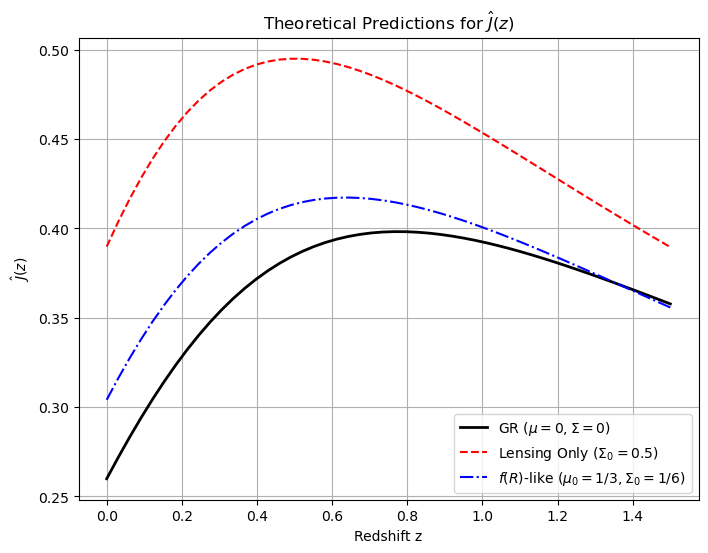

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from scipy.integrate import odeint

# === 1. 参数设置 ===
H0 = 67.5
h = H0 / 100.0
ombh2 = 0.022
omch2 = 0.122
Omega_m0 = (ombh2 + omch2) / h**2
Omega_L0 = 1.0 - Omega_m0  # 假设平坦宇宙

# === 2. 定义修正引力模型 (Phenomenological Parametrization) ===
# 这里我们定义 mu 和 Sigma 随红移的变化
# 例如：正比于暗能量密度 Omega_Lambda(z)
def get_mu_sigma(z, mu0=0.0, sigma0=0.0):
    """
    mu(z) = 1 + mu0 * f(z)
    Sigma(z) = 1 + sigma0 * f(z)
    这里采用常见的 parametrization: f(z) = Omega_Lambda(z) / Omega_Lambda(0)
    """
    # 计算背景 Omega_L(z)
    E2 = Omega_m0 * (1+z)**3 + Omega_L0
    OmL_z = Omega_L0 / E2
    
    # 定义演化函数
    f_z = OmL_z / Omega_L0
    
    mu = 1.0 + mu0 * f_z
    Sigma = 1.0 + sigma0 * f_z
    return mu, Sigma

# === 3. 定义生长方程微分方程 ===
# 线性生长方程: d^2D/da^2 + (3/a + dlnH/da) dD/da - 1.5 * Omega_m(a) * mu(a) * D / a^2 = 0
# 换元到对 ln(a) 求导，令 y = [delta, delta'] (对 lna 的导数)
def growth_ode(y, lna, mu0, sigma0):
    delta, d_delta_d_lna = y
    
    a = np.exp(lna)
    z = 1.0/a - 1.0
    
    # 背景演化 E(z) = H(z)/H0
    E2 = Omega_m0 * (1+z)**3 + Omega_L0
    E = np.sqrt(E2)
    
    # Omega_m(z)
    Om_z = Omega_m0 * (1+z)**3 / E2
    
    # dlnH / dln a = (dH/da) * a / H
    # H^2 ~ a^-3 (matter) + const (Lambda)
    # 2 H dH = -3 Omega_m0 a^-4 da * H0^2
    # dH/da = -1.5 Omega_m0 a^-4 H0^2 / H
    # dlnH/dlna = -1.5 * Omega_m(a)
    dlnH_dlna = -1.5 * Om_z
    
    # 获取修正引力参数 mu
    mu, _ = get_mu_sigma(z, mu0, sigma0)
    
    # 摩擦项系数 (2 + dlnH/dlna)
    friction = 2.0 + dlnH_dlna
    
    # 源项系数 (1.5 * Omega_m * mu)
    source = 1.5 * Om_z * mu
    
    # 核心方程: delta'' + friction * delta' - source * delta = 0
    d2_delta_d_lna2 = -friction * d_delta_d_lna + source * delta
    
    return [d_delta_d_lna, d2_delta_d_lna2]

# === 4. 求解生长历史 ===
def calculate_Jhat_MG(zs, mu0, sigma0, sigma8_0_GR):
    # 初始条件: 高红移 (z=100) 也就是 a 很小，物质主导，假设 GR 成立，delta ~ a
    z_ini = 100.0
    a_ini = 1.0 / (1.0 + z_ini)
    lna_ini = np.log(a_ini)
    
    y0 = [a_ini, a_ini] # delta ~ a, 所以 d(delta)/d(lna) = a
    
    # 生成积分用的 lna 数组 (从早到晚)
    lna_grid = np.log(1.0 / (1.0 + zs))[::-1] # 翻转，让时间正向
    # 加上起点
    lna_eval = np.concatenate(([lna_ini], lna_grid))
    
    # 解微分方程
    sol = odeint(growth_ode, y0, lna_eval, args=(mu0, sigma0))
    
    # 取出结果 (去掉第一个点，并翻转回红移顺序)
    D_MG_unscaled = sol[1:, 0][::-1]
    
    # 我们需要归一化到 z=0 的值
    # 先算 z=0 处的值
    sol_now = odeint(growth_ode, y0, [lna_ini, 0.0], args=(mu0, sigma0))
    D_MG_today = sol_now[-1, 0]
    
    # 归一化 D(z) (使得 D(0)=1)
    D_MG_norm = D_MG_unscaled / D_MG_today
    
    # 注意：这里的 sigma8_MG(z=0) 可能跟 GR 不一样
    # 通常我们固定高红移的物理 (CMB锚定)，所以 sigma8(z=0) 会改变
    # 假设 sigma8(z=large) 与 GR 一致，则 sigma8_MG(0) = sigma8_GR(0) * (D_MG(0)/D_GR(0))_from_high_z
    # 为简单起见，这里假设我们观测到了今天的 sigma8_0，或者用 GR 的作为基准比较形状
    
    # 计算 Omega_m(z) (假设背景不变)
    Hz_array = H0 * np.sqrt(Omega_m0 * (1+zs)**3 + Omega_L0)
    Omega_m_z = Omega_m0 * (1.0 + zs)**3 * (H0 / Hz_array)**2
    
    # 计算 Sigma(z)
    Sigma_vals = np.array([get_mu_sigma(z, mu0, sigma0)[1] for z in zs])
    
    # === 核心公式 ===
    # Jhat = Sigma(z) * Omega_m(z) * sigma8(z)
    # sigma8(z) = sigma8(0) * D(z)
    
    Jhat = Sigma_vals * Omega_m_z * sigma8_0_GR * D_MG_norm
    
    return Jhat

# === 5. 运行比较 ===
# 先跑一遍 CAMB 拿 sigma8_0 的基准值
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)
pars.InitPower.set_params(As=2.1e-9, ns=0.965)
pars.set_matter_power(redshifts=[0.0], kmax=1.0)
results = camb.get_results(pars)
sigma8_0_fid = results.get_sigma8()

zs = np.linspace(0.0, 1.5, 50)

# 计算 GR (mu=0, Sigma=0)
Jhat_GR = calculate_Jhat_MG(zs, mu0=0.0, sigma0=0.0, sigma8_0_GR=sigma8_0_fid)

# 计算 MG1: 只改变光路 (Sigma=0.5, mu=0) -> 模拟你的 mg_A 效应
Jhat_Sigma = calculate_Jhat_MG(zs, mu0=0.0, sigma0=0.5, sigma8_0_GR=sigma8_0_fid)

# 计算 MG2: f(R) 类型 (mu=1/3, Sigma=1/6) -> 物质生长也变快了
Jhat_fR = calculate_Jhat_MG(zs, mu0=0.33, sigma0=0.17, sigma8_0_GR=sigma8_0_fid)

# 画图
plt.figure(figsize=(8,6))
plt.plot(zs, Jhat_GR, 'k-', lw=2, label='GR ($\mu=0, \Sigma=0$)')
plt.plot(zs, Jhat_Sigma, 'r--', label='Lensing Only ($\Sigma_0=0.5$)')
plt.plot(zs, Jhat_fR, 'b-.', label='$f(R)$-like ($\mu_0=1/3, \Sigma_0=1/6$)')

plt.xlabel('Redshift z')
plt.ylabel(r'$\hat{J}(z)$')
plt.title('Theoretical Predictions for $\hat{J}(z)$')
plt.legend()
plt.grid(True)
plt.show()

Chi at z=0.5: 1314.1 Mpc/h
Computing scale dependence for z = 0.5...
Computing scale dependence for z = 0.5...


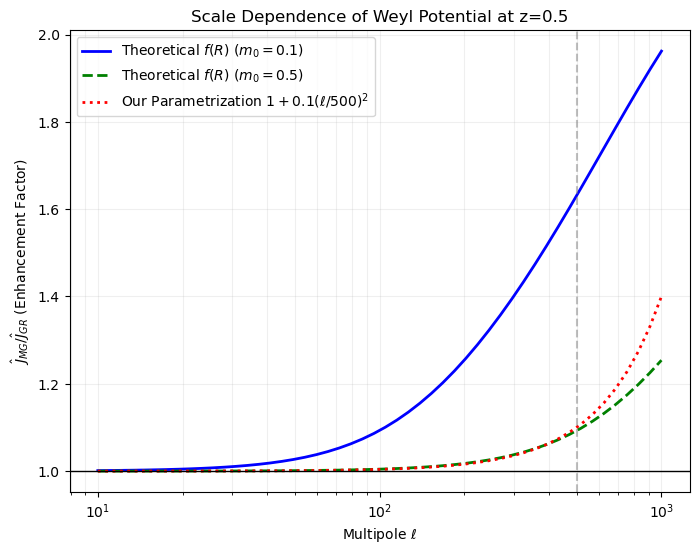

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import camb

# === 1. 基础宇宙学参数 ===
H0 = 67.5
h = H0 / 100.0
Omega_m0 = 0.315
Omega_L0 = 1.0 - Omega_m0

# === 2. 定义尺度依赖的 mu 和 Sigma (Yukawa Model) ===
def get_mu_sigma_k(k, a, mass_0=0.1, alpha=1.0/3.0, beta=1.0/6.0):
    """
    k: 波数 [h/Mpc]
    a: 尺度因子
    mass_0: 标量场质量参数 [h/Mpc] (决定了转折尺度)
    alpha: mu 的增强强度 (f(R)取 1/3)
    beta: Sigma 的增强强度 (f(R)取 1/6)
    """
    # 假设质量随时间演化 m(a) ~ m0 * a^p，这里简化假设 m(a) 随背景密度演化
    # 使得作用范围 lambda_C 随时间变化
    m_a_sq = (mass_0)**2 * a**(-3) 
    
    # 物理波数 k_phys = k / a
    # 汤川修正项 Y = k^2 / (k^2 + m^2 * a^2)
    # 注意：不同文献定义略有不同，这里用共动波数 k 比较方便
    
    Q = k**2 / (k**2 + m_a_sq * a**2)
    
    mu = 1.0 + alpha * Q
    Sigma = 1.0 + beta * Q
    
    return mu, Sigma

# === 3. 生长方程 (带 k 依赖) ===
def growth_ode_k(y, lna, k, mass_0, alpha, beta):
    delta, d_delta_dlna = y
    a = np.exp(lna)
    z = 1.0/a - 1.0
    
    # 背景 H(z)/H0
    E = np.sqrt(Omega_m0 * (1+z)**3 + Omega_L0)
    Om_z = Omega_m0 * (1+z)**3 / E**2
    
    # dlnH / dlna
    dlnH_dlna = -1.5 * Om_z
    
    # === 关键点：这里获取依赖于 k 的 mu ===
    mu, _ = get_mu_sigma_k(k, a, mass_0, alpha, beta)
    
    # 摩擦项和源项
    friction = 2.0 + dlnH_dlna
    source = 1.5 * Om_z * mu
    
    # delta'' + friction*delta' - source*delta = 0
    d2_delta_dlna2 = -friction * d_delta_dlna + source * delta
    
    return [d_delta_dlna, d2_delta_dlna2]

# === 4. 主计算函数 ===
def compute_Jhat_vs_ell(target_z, k_array, mass_0=0.1):
    # 1. 准备积分时间步
    z_ini = 100.0
    lna_ini = np.log(1.0/(1.0+z_ini))
    lna_target = np.log(1.0/(1.0+target_z))
    lna_grid = np.linspace(lna_ini, 0.0, 100) # 积分到今天(z=0)
    
    # 找到 target_z 在 grid 中的索引
    idx_target = np.argmin(np.abs(lna_grid - lna_target))
    
    Jhat_list = []
    
    # 初始条件 (GR at high z)
    y0 = [np.exp(lna_ini), np.exp(lna_ini)]
    
    # 2. 循环计算每一个 k 的生长历史
    # 先算 GR 的基准 (mu=1, Sigma=1) 用于归一化
    sol_GR = odeint(growth_ode_k, y0, lna_grid, args=(1e-5, mass_0, 0, 0)) # alpha=0, beta=0
    D_GR_target = sol_GR[idx_target, 0]
    D_GR_today = sol_GR[-1, 0]
    # GR 的 Jhat = Omega_m(z) * sigma8_GR(z)
    # sigma8_GR(z) ~ D_GR(z)/D_GR(0)
    
    # 计算 target_z 处的 Omega_m
    Hz = H0 * np.sqrt(Omega_m0 * (1+target_z)**3 + Omega_L0)
    Om_z_target = Omega_m0 * (1+target_z)**3 * (H0/Hz)**2
    
    print(f"Computing scale dependence for z = {target_z}...")
    
    for k in k_array:
        # 解当前 k 的微分方程
        # f(R) 参数: alpha=1/3, beta=1/6
        sol_MG = odeint(growth_ode_k, y0, lna_grid, args=(k, mass_0, 1.0/3.0, 1.0/6.0))
        
        D_MG_target = sol_MG[idx_target, 0]
        # D_MG_today = sol_MG[-1, 0] # 如果我们要归一化到今天的 sigma8
        
        # 获取当前的 Sigma(k, z)
        _, Sigma_val = get_mu_sigma_k(k, 1.0/(1+target_z), mass_0, 1.0/3.0, 1.0/6.0)
        
        # === 构造 Jhat (k, z) ===
        # Jhat = Sigma(k,z) * Omega_m(z) * (D_MG(k,z) / D_GR(0)) * sigma8_0_GR
        # 这里我们关注相对 GR 的比例，假设 sigma8_0_GR = 0.8
        
        # 生长增强因子 (Growth Boost)
        growth_boost = D_MG_target / D_GR_target 
        # 注意：这里我们比较的是同一红移下，MG生长了多少 vs GR生长了多少
        # 如果归一化到高红移一致，则 D_MG > D_GR
        
        # Jhat = Sigma * Omega_m * D_GR(z) * Boost * const
        # 简单起见，我们计算 J_MG / J_GR 的比率 (这正是你测量的形状)
        # Ratio = Sigma(k,z) * (D_MG(z)/D_GR(z))
        
        ratio = Sigma_val * growth_boost
        
        # 乘以 GR 的基准值得到绝对值
        # J_GR_val = Om_z_target * (D_GR_target / D_GR_today) * 0.82
        # Jhat_val = ratio * J_GR_val
        
        Jhat_list.append(ratio)

    return np.array(Jhat_list)

# === 5. 执行与绘图 ===
# 设定观测红移
z_lens = 0.5 
# 计算共动距离 chi (用于 k -> ell)
# 简单近似 chi ~ z * 3000 / h (低红移)
# 或者用 CAMB 算更准
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
results = camb.get_results(pars)
chi_lens = results.comoving_radial_distance(z_lens) * h # Mpc/h
print(f"Chi at z={z_lens}: {chi_lens:.1f} Mpc/h")

# 定义 ell 数组
ell_array = np.logspace(1, 3, 50) # 10 到 10000
# 换算为 k (Limber近似)
k_array = (ell_array + 0.5) / chi_lens

# 计算
# Case A: 质量较大 (作用范围小，转折在小尺度) mass_0 = 0.5 h/Mpc
ratios_A = compute_Jhat_vs_ell(z_lens, k_array, mass_0=0.5)

# Case B: 质量较小 (作用范围大，转折在大尺度) mass_0 = 0.1 h/Mpc
ratios_B = compute_Jhat_vs_ell(z_lens, k_array, mass_0=0.1)

# Case C: 你的唯象模型 1 + A * (l/500)^2 (用于对比)
# 设 A 使得在 l=1000 时大概一致
param_model = 1 + 0.1 * (ell_array/500.0)**2 

# 绘图
plt.figure(figsize=(8,6))

# 画出 f(R) 预测 (比率)
plt.semilogx(ell_array, ratios_B, 'b-', lw=2, label=r'Theoretical $f(R)$ ($m_0=0.1$)')
plt.semilogx(ell_array, ratios_A, 'g--', lw=2, label=r'Theoretical $f(R)$ ($m_0=0.5$)')

# 画出你的参数化模型
plt.semilogx(ell_array, param_model, 'r:', lw=2, label=r'Our Parametrization $1+0.1(\ell/500)^2$')

plt.axhline(1.0, color='k', lw=1)
plt.axvline(500, color='gray', alpha=0.5, linestyle='--')

plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\hat{J}_{MG} / \hat{J}_{GR}$ (Enhancement Factor)')
plt.title(f'Scale Dependence of Weyl Potential at z={z_lens}')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [4]:
import numpy as np
from getdist import MCSamples, plots
import os

# chain_path = '/home/wzx/WorkWork/cosmosis_weyl/chains/des-y3-maglim-2x2pt-polychord_noprior_opt.txt'
# chain_path = '/home/wzx/WorkWork/cosmosis_weyl/MyTest//home/wzx/WorkWork/cosmosis_weyl/MyTest/Mychain_first_pess.txt'
chain_path = '/home/wzx/WorkWork/cosmosis_weyl/MyTest/Mychain_NoScaleCut.txt'

# 检查文件类型
if os.path.isfile(chain_path):
    # 如果是单个文件
    data = np.loadtxt(chain_path)
    print(f"数据形状: {data.shape}")
    
    # 读取表头
    with open(chain_path, 'r') as f:
        header = f.readline().strip()
    
    # 解析参数名（跳过第一列？实际上你的数据没有权重列）
    # 从你的数据看，第一行是参数名，数据从第二行开始
    param_names = header.split('\t')
    
    # 检查列数是否匹配
    print(f"参数数量: {len(param_names)}")
    print(f"数据列数: {data.shape[1]}")
    
    # 创建 MCSamples 对象
    # 从你的数据看，最后几列是 prior, post，应该是权重和似然值
    # 通常格式：参数值... weight loglike
    n_params = len(param_names)
    
    # 假设最后两列是 prior 和 post
    samples_data = data[:, :-2]  # 去掉最后两列
    weights = np.ones(data.shape[0])  # 默认权重为1
    loglikes = data[:, -1]  # post 列作为似然值
    
    # 重新命名参数（去掉 -- 后面的部分）
    clean_names = []
    for name in param_names[:-2]:  # 去掉最后两个参数名
        clean_name = name
        clean_names.append(clean_name)
    
    samples = MCSamples(
        samples=samples_data,
        weights=weights,
        loglikes=loglikes,
        names=clean_names,
        labels=clean_names,
        settings={'ignore_rows': 0.7}  # 忽略前30%作为burn-in
    )
    
    print("成功加载样本")
    print(f"参数: {samples.getParamNames().list()}")
    

数据形状: (19200, 37)
参数数量: 37
数据列数: 37
Removed 0.7 as burn in
成功加载样本
参数: ['#cosmological_parameters--omega_m', 'cosmological_parameters--h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 'cosmological_parameters--a_s', 'shear_calibration_parameters--m1', 'shear_calibration_parameters--m2', 'shear_calibration_parameters--m3', 'shear_calibration_parameters--m4', 'wl_photoz_errors--bias_1', 'wl_photoz_errors--bias_2', 'wl_photoz_errors--bias_3', 'wl_photoz_errors--bias_4', 'intrinsic_alignment_parameters--a', 'intrinsic_alignment_parameters--alpha', 'lens_photoz_errors--bias_1', 'lens_photoz_errors--bias_2', 'lens_photoz_errors--bias_3', 'lens_photoz_errors--bias_4', 'lens_photoz_errors--width_1', 'lens_photoz_errors--width_2', 'lens_photoz_errors--width_3', 'lens_photoz_errors--width_4', 'J_bin_bias--jhat1', 'J_bin_bias--jhat2', 'J_bin_bias--jhat3', 'J_bin_bias--jhat4', 'My_J_bin_bias--mg_a', 'b_bin_bias--bhat1', 'b_bin_bias--bhat2', 'b_bin_bias--bhat3', 'b_bin_bias--

Computing theory bands...


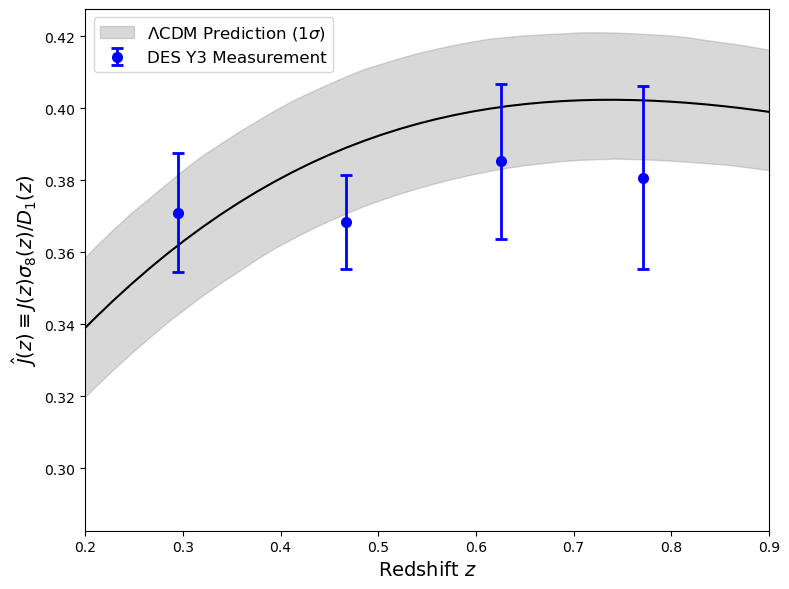

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from getdist import loadMCSamples


# DES MagLim 的 4 个红移分箱的中心红移 (来自文章)
z_bins = np.array([0.295, 0.467, 0.626, 0.771])

# 你的 Jhat 参数在链中的名字 (根据你的 values.ini)
# 注意：如果你用了 J_bin_bias section，名字可能是 'j_bin_bias--jhat1'
param_names_J = [
    'J_bin_bias--jhat1', 
    'J_bin_bias--jhat2', 
    'J_bin_bias--jhat3', 
    'J_bin_bias--jhat4'
]

# 宇宙学参数名字
param_Om = '#cosmological_parameters--omega_m'
param_s8 = 'COSMOLOGICAL_PARAMETERS--SIGMA_8'

# ==========================================
# 2. 辅助函数：计算理论曲线 J_LCDM(z)
# ==========================================
def compute_growth_factor(Om0, z_arr):
    # 解简单的生长方程 (GR)
    # D'' + (2/a + H'/H) D' - 1.5 Om(a)/a^2 D = 0
    def growth_ode(y, a, Om0):
        D, dDda = y
        E = np.sqrt(Om0/a**3 + (1-Om0))
        Om_a = Om0 / (a**3 * E**2)
        # dlnH/da approx
        dlnHda = -1.5 * Om_a / a 
        d2D = -(3/a + dlnHda)*dDda + 1.5 * Om_a * D / a**2
        return [dDda, d2D]
    
    a_arr = 1.0 / (1.0 + z_arr)
    # 从高红移积分到现在
    a_grid = np.linspace(1e-3, 1.0, 500)
    sol = odeint(growth_ode, [1e-3, 1.0], a_grid, args=(Om0,))
    D_raw = sol[:, 0]
    D_norm = D_raw / D_raw[-1] # D(z=0)=1
    
    # 插值回目标 z
    return np.interp(a_arr, a_grid, D_norm)

def get_theory_curve(Om0, sigma8_0, z_arr):
    # 1. 计算 Omega_m(z)
    E2 = Om0 * (1+z_arr)**3 + (1-Om0)
    Om_z = Om0 * (1+z_arr)**3 / E2
    
    # 2. 计算生长因子 D(z)
    D_z = compute_growth_factor(Om0, z_arr)
    
    # 3. 计算 sigma8(z) = sigma8(0) * D(z)
    s8_z = sigma8_0 * D_z
    
    # 4. 理论 J = Om(z) * s8(z)
    return Om_z * s8_z

# ==========================================
# 3. 数据处理
# ==========================================


# --- A. 获取 Jhat 的测量值 (数据点) ---
means = []
errors = []
for p in param_names_J:
    # 获取均值和 1sigma 误差
    m = samples.mean(p)
    s = samples.std(p)
    means.append(m)
    errors.append(s)

means = np.array(means)
errors = np.array(errors)

# --- B. 获取理论曲线的误差带 (阴影) ---
# 从链中随机抽取 1000 个样本，计算 1000 条理论曲线，然后取 68% 区间
print("Computing theory bands...")
z_plot = np.linspace(0.1, 1, 50)
theory_curves = []

# 获取 Omega_m 和 sigma_8 的样本链
# 注意：你需要确保你的链里输出了 sigma_8。如果没有，可能需要用 As 算。
# 假设链里有 derived parameter sigma_8
vals_Om = samples.samples[:, samples.index[param_Om]]
    
vals_s8 = samples.samples[:, samples.index[param_s8]]

# 随机抽 500 个点计算带子
indices = np.random.choice(len(vals_Om), 1000)
for idx in indices:
    om = vals_Om[idx]
    s8 = vals_s8[idx]
    curve = get_theory_curve(om, s8, z_plot)
    theory_curves.append(curve)

theory_curves = np.array(theory_curves)
# 计算 1 sigma 上下限 (16% - 84%)
lower_bound = np.percentile(theory_curves, 16, axis=0)
upper_bound = np.percentile(theory_curves, 84, axis=0)
mean_curve = np.mean(theory_curves, axis=0)

# ==========================================
# 4. 绘图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# 1. 画理论带 (LambdaCDM)
ax.fill_between(z_plot, lower_bound, upper_bound, color='gray', alpha=0.3, label=r'$\Lambda$CDM Prediction ($1\sigma$)')
ax.plot(z_plot, mean_curve, color='black', lw=1.5)

# 2. 画测量点 (你的 Jhat)
ax.errorbar(z_bins, means, yerr=errors, fmt='o', color='blue', 
            capsize=4, elinewidth=2, markeredgewidth=2, 
            label='DES Y3 Measurement')

# 3. 美化
ax.set_xlabel('Redshift $z$', fontsize=14)
ax.set_ylabel(r'$\hat{J}(z) \equiv J(z)\sigma_8(z)/D_1(z)$', fontsize=14)
# ax.set_title('Evolution of the Weyl Potential', fontsize=16)
ax.legend(fontsize=12)
ax.set_xlim(0.2, 0.9)
# 根据你的数据调整 ylim，通常在 0.2 到 0.6 之间
# ax.set_ylim(0.3, 0.45) 

plt.tight_layout()
plt.show()

In [113]:
def read_samples_from_chain(chain_path):  
    import numpy as np
    from getdist import MCSamples

    data = np.loadtxt(chain_path)
    with open(chain_path, 'r') as f:
        header = f.readline().strip()

    param_names = header.split('\t')

    weights = np.ones(data.shape[0])  # 默认权重为1
    loglikes = data[:, -1]  # post 列作为似然值

    samples = MCSamples(
        samples=data,
        weights=weights,
        loglikes=loglikes,
        names=param_names,
        labels=param_names,
        settings={'ignore_rows': 0.7}
    )
    return samples

<>:155: SyntaxWarning: invalid escape sequence '\L'
<>:155: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_178115/4069779067.py:155: SyntaxWarning: invalid escape sequence '\L'
  ax.axhline(1.0, color='k', linestyle='--', label='GR ($\Lambda$CDM)')


Loading chains...
Removed 0.7 as burn in
Measured A = 0.070 ± 0.020
Comoving distance at z=0.5: 1315.1 Mpc/h


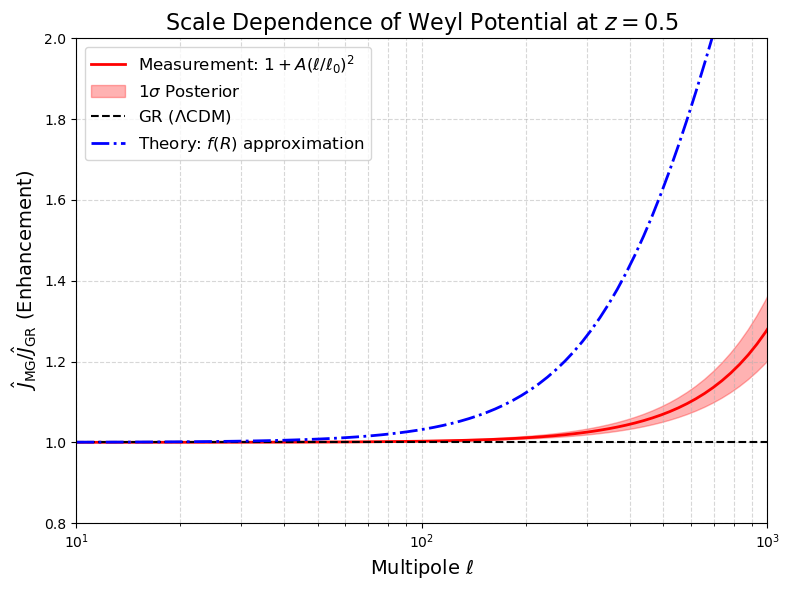

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import camb
from getdist import loadMCSamples

# ==========================================
# 配置部分
# ==========================================
# 1. 你的 MCMC 链路径
chain_path = '/home/wzx/WorkWork/cosmosis_weyl/MyTest/Mychain_NoScaleCut.txt' # 修改为你的路径
# 2. 参数名字 (values.ini 里的名字)
param_A = 'My_J_bin_bias--mg_a' 
# 3. 绘图的目标红移 (比如取透镜的平均红移)
z_target = 0.5
# 4. 枢纽尺度 (和你 MCMC 设置一致)
ell_0 = 500.0
n_index = 2.0

# ==========================================
# 第一部分：从 MCMC 链提取你的测量结果
# ==========================================
print("Loading chains...")
# 自动处理 burn-in
samples = read_samples_from_chain(chain_path)

# 获取 A 的均值和 1-sigma 误差
A_mean = samples.mean(param_A)
A_std = samples.std(param_A)
print(f"Measured A = {A_mean:.3f} ± {A_std:.3f}")

# 定义 ell 范围
ell_plot = np.logspace(1, 3.5, 100) # ell 从 10 到 3000

# 计算唯象模型的曲线: Ratio = 1 + A * (l/l0)^2
def get_phenom_curve(A_val, ell):
    return 1.0 + A_val * (ell / ell_0)**n_index

# 计算误差带
curve_mean = get_phenom_curve(A_mean, ell_plot)
curve_upper = get_phenom_curve(A_mean + A_std, ell_plot)
curve_lower = get_phenom_curve(A_mean - A_std, ell_plot)

# ==========================================
# 第二部分：使用 CAMB + ODE 计算物理理论曲线 (比如 f(R))
# ==========================================

# 1. 设置 CAMB 获取背景演化
pars = camb.CAMBparams()
# 使用 Planck 2018 最佳拟合值作为背景
pars.set_cosmology(H0=67.36, ombh2=0.02237, omch2=0.1200, mnu=0.06, omk=0)
results = camb.get_results(pars)

# 计算目标红移处的共动距离 (用于 k <-> ell 转换)
chi_target = results.comoving_radial_distance(z_target) * 0.6736 # Mpc/h (注意 h 因子)
print(f"Comoving distance at z={z_target}: {chi_target:.1f} Mpc/h")

# 2. 定义修正引力的 mu(k, a) 和 Sigma(k, a)
# 这里以 Hu-Sawicki f(R) 为例
def get_mu_sigma_fR(k, a, fR0):
    # fR0通常取 1e-5 或 1e-6
    # 康普顿波长 lambda_C ~ sqrt(fR0)
    # 简单近似：m^2(a) ~ H0^2 / |fR0| * a^3 (假设背景跟着物质走)
    # k 单位: h/Mpc
    H0_h = 100.0 # h km/s/Mpc -> h/Mpc 单位制下 H0 ~ 1/3000
    c = 3e5
    # 这里的 m 是质量参数，决定转折尺度
    # 唯象处理：转折 k_c ~ 0.1 - 1.0 h/Mpc
    
    # 使用标准汤川形式
    # k_phys = k / a  (如果用共动 k，这就直接是 k)
    # 为了简化演示，我们设定一个固定的特征尺度 k_c
    if fR0 == 0:
        return 1.0, 1.0
    
    k_c = 0.5 # h/Mpc (假设转折在 k=0.5)
    
    Q = k**2 / (k**2 + k_c**2) # 汤川项
    
    mu = 1.0 + (1.0/3.0) * Q
    Sigma = 1.0 + (1.0/6.0) * Q
    return mu, Sigma

# 3. 解生长方程
def growth_ode(y, lna, k, fR0):
    delta, d_delta_dlna = y
    a = np.exp(lna)
    z = 1.0/a - 1.0
    
    # 从 CAMB 获取背景 (Omega_m(z))
    # 简单起见用解析公式近似背景
    Om0 = 0.315
    Ez = np.sqrt(Om0*(1+z)**3 + (1-Om0))
    Om_z = Om0 * (1+z)**3 / Ez**2
    
    dlnH_dlna = -1.5 * Om_z
    
    # 获取 MG 参数
    mu, _ = get_mu_sigma_fR(k, a, fR0)
    
    # 方程
    friction = 2.0 + dlnH_dlna
    source = 1.5 * Om_z * mu
    
    d2_delta = -friction * d_delta_dlna + source * delta
    return [d_delta_dlna, d2_delta]

# 4. 计算理论 Ratio
def compute_theory_ratio(ell_arr, fR0_flag=True):
    ratios = []
    # 积分时间范围
    lna_span = np.linspace(np.log(1e-3), np.log(1.0/(1+z_target)), 100)
    
    # 初始条件 (GR)
    y0 = [np.exp(lna_span[0]), np.exp(lna_span[0])]
    
    # 先算 GR 基准 (fR0=0)
    sol_GR = odeint(growth_ode, y0, lna_span, args=(1e-5, 0)) # k无关
    D_GR = sol_GR[-1, 0]
    
    for ell in ell_arr:
        # Limber: k = (l+0.5)/chi
        k = (ell + 0.5) / chi_target
        
        # 解 MG 方程
        if fR0_flag:
            sol_MG = odeint(growth_ode, y0, lna_span, args=(k, 1)) # 1代表开启MG
            D_MG = sol_MG[-1, 0]
            _, Sigma = get_mu_sigma_fR(k, 1.0/(1+z_target), 1)
        else:
            D_MG = D_GR
            Sigma = 1.0
            
        # J_MG / J_GR = Sigma * (D_MG / D_GR)
        # 注意：这里我们假设高红移归一化相同
        ratio = Sigma * (D_MG / D_GR)
        ratios.append(ratio)
        
    return np.array(ratios)

# 计算 f(R) 理论曲线 (示例)
fR_curve = compute_theory_ratio(ell_plot, fR0_flag=True)


# ==========================================
# 第三部分：绘图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

# 1. 画你的测量结果 (带误差的阴影)
ax.plot(ell_plot, curve_mean, color='red', lw=2, label=r'Measurement: $1 + A(\ell/\ell_0)^2$')
ax.fill_between(ell_plot, curve_lower, curve_upper, color='red', alpha=0.3, label=r'$1\sigma$ Posterior')

# 2. 画 GR 基准线
ax.axhline(1.0, color='k', linestyle='--', label='GR ($\Lambda$CDM)')

# 3. 画 f(R) 理论样条 (示意)
ax.plot(ell_plot, fR_curve, color='blue', linestyle='-.', lw=2, label=r'Theory: $f(R)$ approximation')

# 美化
ax.set_xscale('log')
ax.set_xlabel(r'Multipole $\ell$', fontsize=14)
ax.set_ylabel(r'$\hat{J}_{\mathrm{MG}} / \hat{J}_{\mathrm{GR}}$ (Enhancement)', fontsize=14)
ax.set_title(f'Scale Dependence of Weyl Potential at $z={z_target}$', fontsize=16)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, which='both', linestyle='--', alpha=0.5)

# 限制范围，避免发散太难看
ax.set_ylim(0.8, 2.0)
ax.set_xlim(10, 1000)

plt.tight_layout()
plt.show()

In [123]:
#计算尺度剪切
import numpy as np
import camb

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
results = camb.get_results(pars)

z_means = np.array([0.295, 0.467, 0.626, 0.771])

R_cut_physical = 4

for i,z in enumerate(z_means):
    chi = results.comoving_radial_distance(z) * (67.5/100.0)  # Mpc/h计算共动距离
    theta_rad = R_cut_physical / chi  # 弧度
    theta_arcmin = theta_rad * (180.0/np.pi) * 60  # 转换为角分
    print(f"Bin {i+1} (z={z}): R_cut = {R_cut_physical} Mpc 对应 θ_cut = {theta_arcmin:.2f} arcmin")


Bin 1 (z=0.295): R_cut = 4 Mpc 对应 θ_cut = 16.77 arcmin
Bin 2 (z=0.467): R_cut = 4 Mpc 对应 θ_cut = 11.10 arcmin
Bin 3 (z=0.626): R_cut = 4 Mpc 对应 θ_cut = 8.66 arcmin
Bin 4 (z=0.771): R_cut = 4 Mpc 对应 θ_cut = 7.32 arcmin


In [1]:
import numpy as np
import camb

# ================= 配置区域 =================
# 宇宙学参数 (DES Y3 Best Fit 或 Planck)
H0 = 67.5
Om0 = 0.315

# 你关心的红移点 (DES MagLim 4 bins)
z_targets = [0.295, 0.467, 0.626, 0.771]

# 你想要查询的 k 值 (h/Mpc)
k_queries = [0.005, 0.05, 0.5]

# 你想要查询的 theta 值 (arcmin)
theta_queries = [2.82, 10, 25, 224]

# ================= 计算核心 =================
def get_conversion_tool():
    # 初始化 CAMB
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=0.022, omch2=Om0*(H0/100)**2-0.022)
    results = camb.get_results(pars)
    
    return results

def run_calculator():
    results = get_conversion_tool()
    
    print(f"{'='*60}")
    print(f"Cosmology: H0={H0}, Omega_m={Om0}")
    print(f"{'='*60}\n")

    # --- 场景 1: 给定 k (h/Mpc) -> 查 ell 和 theta ---
    print(f"--- Scenario 1: Given physical k [h/Mpc] ---")
    print(f"{'z':<6} {'k':<8} | {'ell':<8} {'theta (arcmin)':<15}")
    print("-" * 45)
    
    for z in z_targets:
        # 共动距离 (Mpc/h)
        chi = results.comoving_radial_distance(z) * (H0/100.0)
        
        for k in k_queries:
            # Limber: ell = k * chi
            ell = k * chi
            # theta = 180*60 / (pi * ell) ... 近似 10800/ell
            # 精确: theta = (1/k_phys) / chi_phys ... = 1 / (k*chi) rad
            theta_rad = 1.0 / ell
            theta_arcmin = theta_rad * (180.0 / np.pi) * 60.0
            
            print(f"{z:<6.3f} {k:<8.2f} | {ell:<8.1f} {theta_arcmin:<15.2f}")
        print("-" * 45)

    print("\n")

    # --- 场景 2: 给定 theta (arcmin) -> 查 k ---
    print(f"--- Scenario 2: Given angular theta [arcmin] ---")
    print(f"{'z':<6} {'theta':<8} | {'ell':<8} {'k (h/Mpc)':<15}")
    print("-" * 45)
    
    for z in z_targets:
        chi = results.comoving_radial_distance(z) * (H0/100.0)
        
        for theta in theta_queries:
            theta_rad = theta / (60.0 * 180.0) * np.pi
            ell = 1.0 / theta_rad
            k = ell / chi
            
            print(f"{z:<6.3f} {theta:<8.1f} | {ell:<8.1f} {k:<15.3f}")
        print("-" * 45)

if __name__ == "__main__":
    run_calculator()

Cosmology: H0=67.5, Omega_m=0.315

--- Scenario 1: Given physical k [h/Mpc] ---
z      k        | ell      theta (arcmin) 
---------------------------------------------
0.295  0.01     | 4.1      838.16         
0.295  0.05     | 41.0     83.82          
0.295  0.50     | 410.2    8.38           
---------------------------------------------
0.467  0.01     | 6.2      554.90         
0.467  0.05     | 62.0     55.49          
0.467  0.50     | 619.5    5.55           
---------------------------------------------
0.626  0.01     | 7.9      432.63         
0.626  0.05     | 79.5     43.26          
0.626  0.50     | 794.6    4.33           
---------------------------------------------
0.771  0.01     | 9.4      365.70         
0.771  0.05     | 94.0     36.57          
0.771  0.50     | 940.1    3.66           
---------------------------------------------


--- Scenario 2: Given angular theta [arcmin] ---
z      theta    | ell      k (h/Mpc)      
-------------------------------------